In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from sklearn.preprocessing import StandardScaler

import random
from datetime import datetime
from scipy.stats import skewnorm
from IPython.display import clear_output
import re

import ipycytoscape
import torch

from pyvis.network import Network
import os


DEBUG = True
SAVE_PATH = "timeseries_GMAN_model_flow_loss_v4.pth"

In [ ]:
def create_skewed_series(n_points, max_val, skewness, sigma=1.0):
    """
    Generates a pandas Series of random numbers following a Skew Normal distribution,
    shifted so the maximum value equals 'max_val'.

    Args:
        n_points (int): The number of data points to generate.
        max_val (float): The maximum value (ceiling) of the dataset.
        skewness (float): The skew factor. 
                          0 = Normal distribution (symmetric).
                          Positive = Tail on the right (mass on left).
                          Negative = Tail on the left (mass on right).
        sigma (float): The scale (standard deviation) or 'width' of the curve.

    Returns:
        pd.Series: A Series containing the generated data.
    """
    # 1. Generate the raw Skew Normal distribution
    # 'a' is the skewness parameter
    # 'loc' is the mean, 'scale' is the standard deviation (sigma)
    raw_data = skewnorm.rvs(a=skewness, loc=0, scale=sigma, size=n_points)

    # 2. Shift the data to respect the 'max_val' constraint
    # We find the current generated max, and shift the whole dataset
    # so that the new max hits your target exactly.
    current_max = np.max(raw_data)
    shift_amount = max_val - current_max
    final_data = raw_data + shift_amount

    return pd.Series(final_data)

def create_day_demand(day:datetime, node:str, amp_range:int = (60, 100), skewness_range:int = (-6,-3), sigma_range:int = (7, 10), nn:int = 1440, points:int = 24):

    _max_val = random.randint(amp_range[0], amp_range[1])
    _skewness = random.randint(skewness_range[0], skewness_range[1])
    _sigma = random.randint(sigma_range[0], sigma_range[1])

    #print(f"Node: {node}, Max Val: {_max_val}, Skewness: {_skewness}, Sigma: {_sigma}")
    _curve = create_skewed_series(5000, _max_val, skewness=_skewness, sigma=_sigma)
    _curve = _curve.value_counts(bins=points).sort_index().reset_index(drop=True)
    _curve.name = node
    _curve.index = pd.date_range(start=day, periods=points, freq='h')
    _curve = _curve * _max_val/_curve.max()

    return _curve

def calculate_edge_flows(G, demands, capacity_attr='capacity'):
    """
    Calculates the flow through all edges in a Digraph to satisfy specific node demands.
    
    Args:
        G (nx.DiGraph): The networkx graph. Edges must have a capacity attribute.
        demands (dict): Dictionary {node_name: required_output_flow}.
        capacity_attr (str): The name of the edge attribute representing capacity.
        
    Returns:
        dict: A dictionary of dictionaries representing flow {u: {v: flow_amount}}.
    """
    # 1. Create a working copy of the graph to avoid modifying the original
    R = G.copy()
    
    # 2. Define Super Node names (ensure they don't clash with existing nodes)
    super_source = 'SUPER_SOURCE_VIRTUAL'
    super_sink = 'SUPER_SINK_VIRTUAL'
    
    # 3. Add the Super Sink
    # Connect demand nodes to Super Sink with capacity = demand
    total_demand = 0
    for node, demand in demands.items():
        if node not in R:
            raise ValueError(f"Demand node '{node}' is not in the graph.")
        R.add_edge(node, super_sink, **{capacity_attr: demand})
        total_demand += demand

    # 4. Add the Super Source
    # Identify potential sources: Nodes with 0 in-degree that aren't the super sink
    # If specific sources are known, you can pass them as a list instead of this auto-detection
    sources = [n for n in G.nodes() if G.in_degree(n) == 0]
    
    if not sources:
        # If the graph is a cycle (no 0 in-degree nodes), we might need to assume 
        # all non-demand nodes are potential sources, or raise an error.
        # Here, we default to connecting to all nodes that aren't sinks.
        sources = [n for n in G.nodes() if n not in demands]

    for source in sources:
        # Connect Super Source to sources with Infinite capacity
        R.add_edge(super_source, source, **{capacity_attr: float('inf')})

    # 5. Compute Maximum Flow
    try:
        flow_value, flow_dict = nx.maximum_flow(R, super_source, super_sink, capacity=capacity_attr)
    except nx.NetworkXError as e:
        print(f"Error computing flow: {e}")
        return {}

    # 6. Check if demands were met
    if flow_value < total_demand:
        print(f"WARNING: The network capacity ({flow_value}) is insufficient to meet total demand ({total_demand}).")
        print("Returning partial flow assignments.")

    # 7. Clean up the output
    # The flow_dict includes the virtual nodes; we need to strip them out.
    final_flow = {}
    for u, neighbors in flow_dict.items():
        # Skip if u is a virtual node
        if u in (super_source, super_sink):
            continue
            
        final_flow[u] = {}
        for v, flow in neighbors.items():
            # Skip if v is a virtual node
            if v in (super_source, super_sink):
                continue
            final_flow[u][v] = flow

    final_flow_df = pd.DataFrame(final_flow).stack().to_frame().rename(columns={0: 'Flow'}).swaplevel()

    return final_flow_df

    """
    Visualizes a networkx Graph with flow values from a pandas Series.
    
    Parameters:
    - G: networkx.Graph or DiGraph
    - flow_series: pd.Series where index is edges (u,v) and values are floats.
    """
    
    # 1. Setup Figure
    plt.figure(figsize=(14, 10), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    # 2. Generate "Spread" Layout
    # We scale 'k' (repulsive force) based on node count to keep it sparse
    k_val = 2.0 / np.sqrt(len(G.nodes())) if len(G.nodes()) > 0 else 1
    pos = nx.spring_layout(G, k=k_val, iterations=50, seed=42)

    # 3. Process Edge Styles
    edge_colors = []
    edge_widths = []
    edge_labels = {}
    
    # Handle empty series or all zeros
    if flow_series.empty:
        max_val = 1.0
    else:
        max_val = flow_series.max()
        if max_val == 0: max_val = 1.0

    for u, v in G.edges():
        # Retrieve flow safely, checking both (u,v) and (v,u)
        val = 0.0
        if (u, v) in flow_series.index:
            val = flow_series.loc[(u, v)]
        elif (v, u) in flow_series.index:
            val = flow_series.loc[(v, u)]
        
        # Color: Map value directly
        edge_colors.append(val)
        
        # Width: Base width (1.0) + scaled extra width (up to 6.0)
        width_scale = 1.0 + (val / max_val) * 6.0
        edge_widths.append(width_scale)
        
        # Label: formatted string
        edge_labels[(u, v)] = f"{val:.1f}"

    # 4. Draw Components
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightgrey', edgecolors='black')
    
    # Draw Node Labels
    nx.draw_networkx_labels(G, pos, font_color='black', font_weight='bold')

    # Draw Edges
    # We use a colormap (Blues) to visualize intensity
    cmap = plt.cm.Blues
    nx.draw_networkx_edges(G, pos, 
                           width=edge_widths, 
                           edge_color=edge_colors, 
                           edge_cmap=cmap, 
                           edge_vmin=0, 
                           edge_vmax=max_val,
                           arrows=True, arrowstyle='-|>', arrowsize=20)
    
    # Draw Flow Values (with white background for readability)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                                 font_color='black', font_size=10,
                                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

    # 5. Add Colorbar (Robust Method)
    # Create a 'ScalarMappable' explicitly to avoid AttributeError
    norm = mcolors.Normalize(vmin=0, vmax=max_val)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Flow Magnitude', color='black', size=12)
    cbar.ax.yaxis.set_tick_params(color='black', labelcolor='black')

    # 6. Final Polish
    plt.title(title, fontsize=16, color='black')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def analyze_specific_flow(flow_dict):
    # 2. Reconstruct the Graph from the keys
    G = nx.DiGraph()
    G.add_edges_from(flow_dict.keys())
    
    # 3. Auto-detect Sources and Sinks
    # Sources = Nodes with In-Degree 0
    sources = [n for n in G.nodes if G.in_degree(n) == 0]
    # Sinks = Nodes with Out-Degree 0
    sinks = [n for n in G.nodes if G.out_degree(n) == 0]
    
    print(f"Detected Sources (Inputs): {sources}")
    print(f"Detected Sinks (Outputs): {sinks}")
    
    results = []
    
    # 4. Calculate Balance for Internal Nodes
    for node in G.nodes:
        if node in sources or node in sinks:
            continue
            
        flow_in = 0.0
        flow_out = 0.0
        
        # Sum Inputs
        for u in G.predecessors(node):
            flow_in += flow_dict.get((u, node), 0.0)
            
        # Sum Outputs
        for v in G.successors(node):
            flow_out += flow_dict.get((node, v), 0.0)
            
        balance = flow_in - flow_out
        
        # Determine status
        if abs(balance) < 1e-4:
            status = "✅ Balanced"
        elif balance > 0:
            status = "⚠️ Accumulation (In > Out)"
        else:
            status = "🔻 Leak/Gain (Out > In)" # Out is higher, so flow appeared
            
        results.append({
            "Node": node,
            "Flow In": round(flow_in, 3),
            "Flow Out": round(flow_out, 3),
            "Diff": round(balance, 3),
            "Status": status
        })
        
    #return pd.DataFrame(results).set_index("Node")
    return pd.DataFrame(results).set_index("Node").Diff.mean()

    """
    Generates a dynamic HTML graph from a dictionary of edge flows.
    
    Args:
        flow_dict (dict): Format {(Source, Target): flow_value}
        output_file (str): Name of the output HTML file.
        show_buttons (bool): If True, adds a UI to tweak physics/layout.
    """
    
    # 1. Initialize the NetworkX Directed Graph
    G = nx.DiGraph()
    
    # Track min/max flow for normalization (to scale edge thickness)
    flows = list(flow_dict.values())
    if not flows:
        print("Dictionary is empty.")
        return
        
    min_flow = min(flows)
    max_flow = max(flows)
    
    # Avoid division by zero if all flows are the same
    norm_range = max_flow - min_flow if max_flow != min_flow else 1

    # 2. Build the graph
    for (source, target), flow in flow_dict.items():
        # Calculate distinct visual weight (scale between 1 and 10)
        # Formula: 1 + ((flow - min) / range) * 9
        visual_width = 1 + ((flow - min_flow) / norm_range) * 9
        
        G.add_edge(
            source, 
            target, 
            value=flow,           # Stored metadata
            title=f"Flow: {flow}", # Tooltip on hover
            label=str(flow),      # Text on the arrow
            width=visual_width,   # Thickness of the line
            arrowStrikethrough=False
        )

    # 3. Initialize PyVis Network
    # height/width '100%' makes it fill the browser window
    net = Network(height="750px", width="100%", directed=True, notebook=False)
    
    # 4. Load the NetworkX graph into PyVis
    net.from_nx(G)

    # 5. Customize Physics and Appearance
    # This sets a specific physics layout that spreads nodes nicely
    net.barnes_hut(gravity=-2000, central_gravity=0.3, spring_length=95)
    
    if show_buttons:
        # Adds a control panel to the UI to play with layout physics dynamically
        net.show_buttons(filter_=['physics'])

    # 6. Save/Show result
    # We use write_html to ensure compatibility across environments
    net.write_html(output_file)
    
    print(f"Graph successfully generated: {os.path.abspath(output_file)}")
    # If you are in Jupyter, you can return IFrame or let it display:
    # return net.show(output_file)

def visualize_flow_series(data:pd.Series):
    G_vis = nx.DiGraph()
    for k,v in data.items():
        G_vis.add_edge(k[0],k[1],weight=round(v,1))
        
    cyto = ipycytoscape.CytoscapeWidget()
    cyto.graph.add_graph_from_networkx(G_vis)

    cyto.set_style([
        {
            'selector': 'node',
            'style': {
                'label': 'data(id)',
                'background-color': '#0074D9',
                'color': 'white',
                'text-valign': 'center',
                'text-halign': 'center',
                'width': '40px',
                'height': '40px',
                'font-size': '15px',
            }
        },
        {
            'selector': 'edge',
            'style': {
                'label': 'data(weight)',  
                'width': 'mapData(weight, 0, 10, 1, 8)',
                'line-color': '#9dbaea',
                'target-arrow-shape': 'triangle',
                'curve-style': 'bezier',
                'font-size': '15px',
                'color': '#555'
            }
        }
    ])

    # 4. Configure "Gravity" (Repulsion)
    # 'nodeRepulsion' controls how much they push away from each other
    cyto.set_layout(
        name='cose',
        nodeRepulsion=400000, 
        idealEdgeLength=100,
        gravity=80
    )

    cyto.layout.width = '100%'   
    cyto.layout.height = '600px'

    return cyto


G = nx.DiGraph()
G.add_edge('HR_A', 'MR_A', capacity=10000)
G.add_edge('HR_B', 'MR_B', capacity=10000)
G.add_edge('MR_B', 'MR_A', capacity=10000)
G.add_edge('MR_A', 'C', capacity=10000)

G.add_edge('C', 'D', capacity=10000)
G.add_edge('MR_B', 'A', capacity=10000)
G.add_edge('A', 'B', capacity=10000)
G.add_edge('B', 'D', capacity=10000)
G.add_edge('D', 'E', capacity=10000)

G.add_edge('C', 'S7', capacity=10000)
G.add_edge('D', 'S6', capacity=10000)
G.add_edge('D', 'S5', capacity=10000)
G.add_edge('B', 'S3', capacity=10000)
G.add_edge('A', 'S1', capacity=10000)
G.add_edge('A', 'S2', capacity=10000)
G.add_edge('E', 'S4', capacity=10000)


DEMANDS_NODES = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']
DAY_START = datetime(2024, 1, 1)
RANGE_MONTHS = 6
RANGE_DATE = pd.date_range(start=DAY_START, periods=RANGE_MONTHS*30, freq='D')


DEMANDS = []
for _day in RANGE_DATE:
    _demands_day = {}
    for _node in DEMANDS_NODES:
        _demands_day[_node] = create_day_demand(_day, _node)
    DEMANDS.append(pd.DataFrame(_demands_day))

DEMANDS = pd.concat(DEMANDS)




'\nRAW_DATA = pd.DataFrame()\nfor k,v in DEMANDS.iterrows():\n    _flow = calculate_edge_flows(G, v.to_dict() )\n    _flow.columns = [k]   \n    RAW_DATA = pd.concat([RAW_DATA, _flow], axis=1)\n\nclear_output()\n\n# SIULATING NOISE\nNOISE =  np.random.normal(loc=0, scale=0.05, size=RAW_DATA.shape)\nRAW_DATA = RAW_DATA*(1+NOISE)\n\n#display(RAW_DATA.T.plot(figsize=(20,10)))\n\ntimestamp = RAW_DATA.sum().idxmax() #RAW_DATA.T.sample().index[0]\nprint()\n#visualize_flow_series(RAW_DATA.loc[:,timestamp])\n\n'

2024-04-30 07:00:00


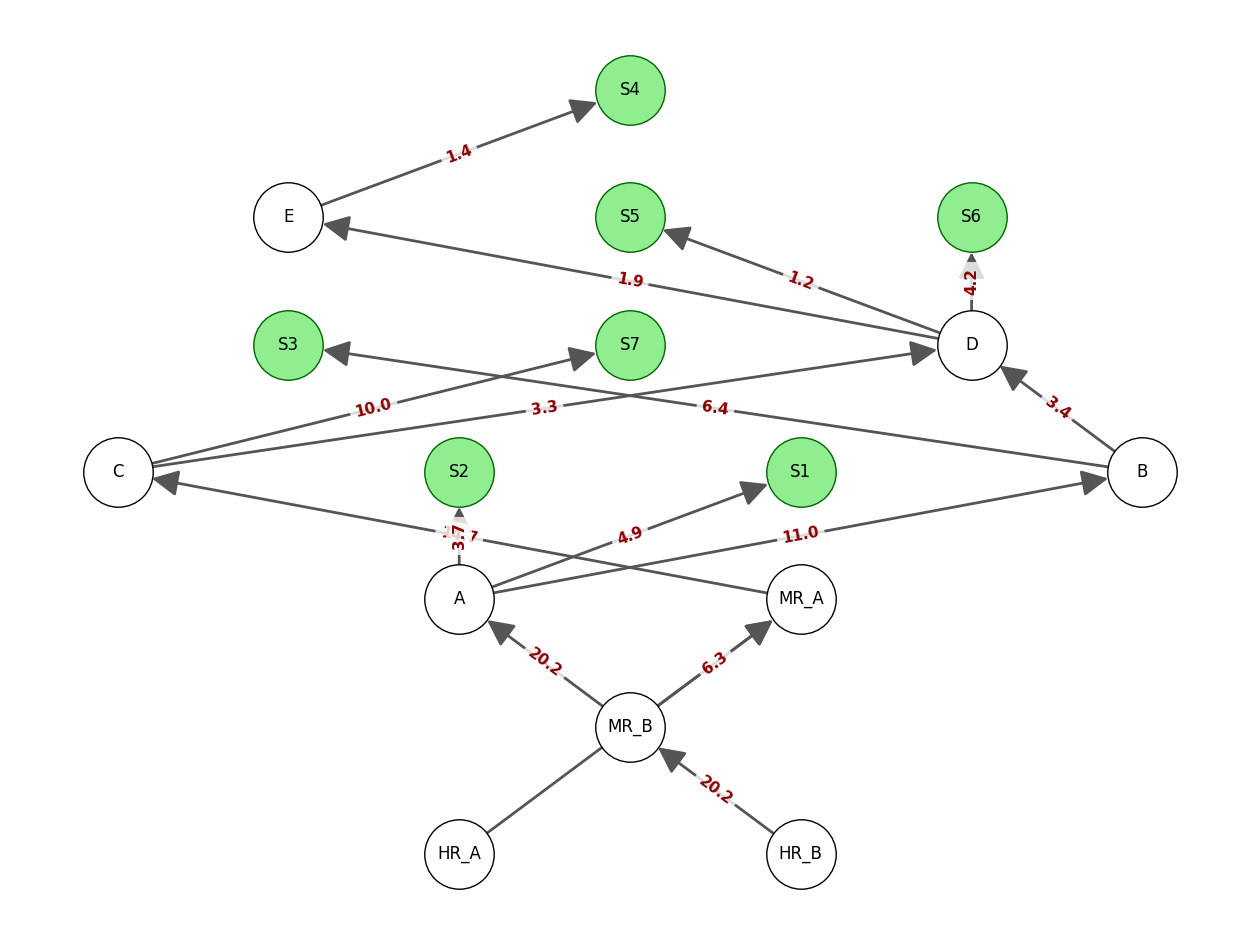

In [ ]:
def propagate_demand_upwards(G: nx.DiGraph, flow_attr='flow') -> nx.DiGraph:
    """
    Calculates flow for all edges in a DAG by propagating demand from 
    bottom leaf edges upwards to the top sources.
    
    Args:
        G: A NetworkX DiGraph (must be Acyclic).
           'Leaf edges' (edges pointing to nodes with out_degree=0) must 
           have the 'flow' attribute set.
        flow_attr: The attribute name for the flow value.
        
    Returns:
        The DiGraph with calculated flows on all edges.
    """
    # Work on a copy to preserve original structure
    H = G.copy()

    # 1. Verification: Ensure it is a DAG (Cycles break Kirchhoff's logic)
    if not nx.is_directed_acyclic_graph(H):
        raise ValueError("Graph contains a cycle. Kirchhoff propagation requires a DAG.")

    # 2. Initialize flow on non-leaf edges to 0 to be safe
    for u, v, data in H.edges(data=True):
        if flow_attr not in data:
            data[flow_attr] = 0.0

    # 3. Get Reverse Topological Sort
    # We process children before parents.
    # The last nodes in a topo sort are the leaves; reversed means we start with them.
    try:
        nodes_bottom_up = list(reversed(list(nx.topological_sort(H))))
    except nx.NetworkXUnfeasible:
        raise ValueError("Graph cycle detected during sort.")

    # 4. Propagate Flow Upwards
    for node in nodes_bottom_up:
        # Step A: Calculate how much this node OUTPUTS (Demand)
        out_edges = H.out_edges(node, data=True)
        
        # If it's a leaf node, it doesn't output to other nodes, 
        # but the edges *entering* it carry the flow we start with.
        # We need to calculate the flow for the edges ENTERING this node.
        
        # Calculate the total flow leaving this node
        total_out_flow = sum(data.get(flow_attr, 0.0) for _, _, data in out_edges)
        
        # NOTE: If this is a true "Leaf" (out_degree=0), total_out_flow is 0.
        # But wait - the prompt says "flow is attribute in the LEAF EDGES".
        # This implies the edges *entering* the leaves already have values.
        # So we actually need to process 'Internal Nodes' that feed these leaves.
        
        # If total_out_flow is 0, check if this node is a sink that was manually set?
        # No, the flow is on the *edge*. 
        # So if I am Node B, and I point to Leaf C (B->C), B->C has flow.
        # I just summed B->C. Now I need to supply B's parents.

        # Step B: Identify Parents (Incoming Edges)
        in_edges = list(H.in_edges(node))
        num_parents = len(in_edges)

        if num_parents > 0:
            # If the node has output flow, it must request that amount from inputs.
            # However, if this node is a Leaf, it has NO output edges.
            # But the edge pointing TO it (Parent->Leaf) is the one with the value.
            # We don't need to calculate the flow for the edge pointing to the leaf 
            # (it's already there). We need to calculate the flow for the Parent's Parent.
            
            # So, strictly speaking, we only need to act if we are an INTERNAL node
            # whose out-edges have just been summed up.
            
            # If total_out_flow > 0, we propagate it up.
            if total_out_flow > 0:
                flow_per_parent = total_out_flow / num_parents
                
                for parent, _ in in_edges:
                    # Set the flow for the incoming edge (Parent -> Node)
                    # We use += because a parent might have multiple children 
                    # causing it to accumulate demand from different branches.
                    # BUT: Since we initialize to 0 and visit each edge once from the child side,
                    # we can technically just set it, but += is safer for aggregation logic.
                    
                    current_val = H[parent][node].get(flow_attr, 0.0)
                    
                    # If this edge was a "leaf edge" preset by the user, we shouldn't overwrite it?
                    # The user said leaf edges have attributes. Upper edges don't.
                    # We only overwrite if it's 0 (calculated).
                    if current_val == 0.0:
                         H[parent][node][flow_attr] = flow_per_parent
                    else:
                        # If the edge already has flow (e.g., it's a leaf edge), 
                        # we use that value for the sum, but we don't change it.
                        pass

    return H

def draw_flow_graph_spaced(G, flow_attr='flow', spacing=2.0):
    plt.figure(figsize=(8 * spacing, 6 * spacing))
    
    # 1. Layout logic
    for layer, nodes in enumerate(nx.topological_generations(G)):
        for node in nodes: 
            G.nodes[node]['layer'] = layer
    pos = nx.multipartite_layout(G, subset_key='layer', align='horizontal', scale=spacing)

    # 2. Identify Nodes
    leaf_nodes = [n for n, d in G.out_degree() if d == 0]
    regular_nodes = [n for n in G.nodes() if n not in leaf_nodes]

    # 3. Draw Nodes (Draw these first)
    nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes, node_size=2500, node_color='white', edgecolors='black')
    nx.draw_networkx_nodes(G, pos, nodelist=leaf_nodes, node_size=2500, node_color='lightgreen', edgecolors='darkgreen')
    nx.draw_networkx_labels(G, pos, font_size=12)

    # 4. Draw Edges (PUT ARROWS HERE)
    nx.draw_networkx_edges(
        G, pos, 
        node_size=2500,          # Tells arrows where to stop so they are visible
        arrows=True,              # Valid here
        arrowstyle='-|>',         # Solid triangle head
        arrowsize=40,             # Large enough to see
        edge_color='#555555', 
        width=2,
        min_target_margin=25      # Forces the arrow tip to stay outside the node circle
    )

    # 5. Draw Edge Labels (TEXT ONLY)
    edge_labels = {
        (u, v): f"{d[flow_attr]:.1f}" 
        for u, v, d in G.edges(data=True) if flow_attr in d
    }
    
    nx.draw_networkx_edge_labels(
        G, pos, 
        edge_labels=edge_labels, # No 'arrows' or 'arrow' argument here!
        font_color='darkred', 
        font_size=11, 
        font_weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
    )

    plt.axis('off')
    plt.show()

def draw_flow_graph_spaced_df(G,df):

    _attr = df.columns[-1]
    print(_attr)
   
    _h = nx.from_pandas_edgelist(df, 
                            source=0, 
                            target=1, 
                            edge_attr=True, 
                            create_using=nx.DiGraph()
                            )

    draw_flow_graph_spaced(_h, flow_attr=_attr)
    

def reconsruct_flows(G, flows:dict):
    H = G.copy()

    for _leaf_node,_flow in flows.items():
        _edge_leaf = [x for x in H.edges() if x[1] == _leaf_node]
        H.edges[_edge_leaf[0]]["flow"] = float(_flow)

    H = propagate_demand_upwards(H)
    return H



################# CREATING GRAPH #######################
G = nx.DiGraph()
G.add_edge('HR_A', 'MR_A', capacity=10000)
G.add_edge('HR_B', 'MR_B', capacity=10000)
G.add_edge('MR_B', 'MR_A', capacity=10000)
G.add_edge('MR_A', 'C', capacity=10000)

G.add_edge('C', 'D', capacity=10000)
G.add_edge('MR_B', 'A', capacity=10000)
G.add_edge('A', 'B', capacity=10000)
G.add_edge('B', 'D', capacity=10000)
G.add_edge('D', 'E', capacity=10000)

G.add_edge('C', 'S7', capacity=10000)
G.add_edge('D', 'S6', capacity=10000)
G.add_edge('D', 'S5', capacity=10000)
G.add_edge('B', 'S3', capacity=10000)
G.add_edge('A', 'S1', capacity=10000)
G.add_edge('A', 'S2', capacity=10000)
G.add_edge('E', 'S4', capacity=10000)

################# CREATING DEMANDS #######################

DEMANDS_NODES = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7']
DAY_START = datetime(2024, 1, 1)
RANGE_MONTHS = 6
RANGE_DATE = pd.date_range(start=DAY_START, periods=RANGE_MONTHS*30, freq='D')


DEMANDS = []
for _day in RANGE_DATE:
    _demands_day = {}
    for _node in DEMANDS_NODES:
        _demands_day[_node] = create_day_demand(_day, _node)
    DEMANDS.append(pd.DataFrame(_demands_day))

DEMANDS = pd.concat(DEMANDS)


##### CREATING ROW DATA ###########################################
RAW_DATA = []
for _date,_flows in DEMANDS.iterrows():
    _flows_dict = _flows.to_dict()
    _flows_h = reconsruct_flows(G,_flows_dict).edges(data=True)
    _flows_df = pd.DataFrame([(x[0],x[1],x[2]['flow']) for x in _flows_h]).set_index([0,1]).rename(columns={2:_date}).T 
    RAW_DATA.append(_flows_df) 
    clear_output()
    print(_date)
clear_output()

RAW_DATA = pd.concat(RAW_DATA)

############################################## SIULATING NOISE
NOISE =  np.random.uniform(-0.2, 0.2,size=RAW_DATA.shape)
RAW_DATA = RAW_DATA*(1+NOISE)
RAW_DATA = RAW_DATA.T

## TEST FLOW
draw_flow_graph_spaced_df(G, RAW_DATA.sample(1).reset_index() )


<Axes: >

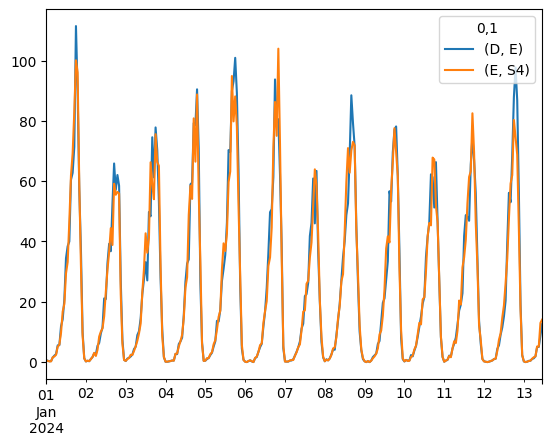

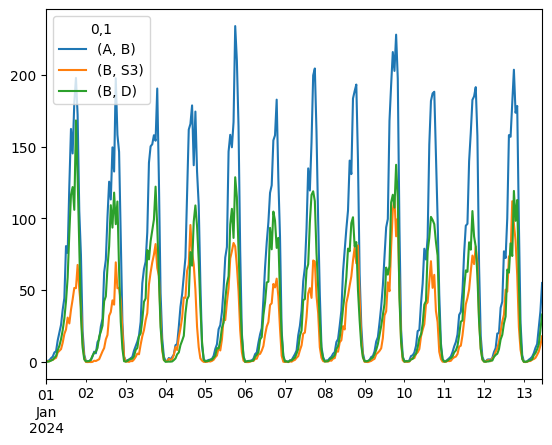

In [64]:
RAW_DATA.loc[[('D','E'),('E','S4')]].iloc[:,:300].T.plot()
RAW_DATA.loc[[('A','B'),('B','S3'),('B','D')]].iloc[:,:300].T.plot()

## PREPARATION OF DATA

In [76]:
SAMPLING = '1h'
TSS = RAW_DATA.T.copy()
TSS = TSS.resample(SAMPLING).mean()
TSS = TSS[TSS.index.month.isin(TSS.index.month.unique()[-8:])]
TSS.columns.names = ['from','to']

TSS

from                      HR_A        MR_A        HR_B       MR_B              \
to                        MR_A           C        MR_B       MR_A           A   
2024-01-01 00:00:00   0.391814    0.748104    2.109811   0.478601    1.286410   
2024-01-01 01:00:00   0.277751    0.559412    1.308868   0.212841    1.217738   
2024-01-01 02:00:00   0.398537    0.817105    2.717073   0.370109    2.026620   
2024-01-01 03:00:00   0.623398    1.150251    5.288011   0.659062    3.719652   
2024-01-01 04:00:00   1.074311    2.193830    6.869939   1.147397    5.959657   
...                        ...         ...         ...        ...         ...   
2024-06-28 19:00:00  74.561956  152.413018  295.343317  78.258093  246.947063   
2024-06-28 20:00:00  46.897449   91.791512  184.096998  56.174201  193.394949   
2024-06-28 21:00:00  28.960182   64.122319   97.783323  24.613012   98.125518   
2024-06-28 22:00:00   9.064063   15.347043   44.292944   8.502686   33.804115   
2024-06-28 23:00:00   2.000275    3.837238    6.401091   1.389822    6.850264   

from                         C                     D                        \
to                           D         S7          E         S6         S5   
2024-01-01 00:00:00   0.663406   0.293679   0.626304   0.370941   0.298360   
2024-01-01 01:00:00   0.212662   0.287933   0.465893   0.000000   0.000000   
2024-01-01 02:00:00   0.718962   0.104896   0.272569   0.117804   0.854395   
2024-01-01 03:00:00   0.907746   0.242940   0.323779   0.391107   1.302968   
2024-01-01 04:00:00   1.862145   0.509594   1.513996   0.250263   1.865545   
...                        ...        ...        ...        ...        ...   
2024-06-28 19:00:00  68.549934  57.549340  75.563560  32.460137  45.095427   
2024-06-28 20:00:00  59.212705  53.119649  82.206027  20.759643  40.356020   
2024-06-28 21:00:00  33.207119  22.179230  46.643802   6.844623  16.354215   
2024-06-28 22:00:00  11.163458   6.905123  18.718735   2.724547   3.499850   
2024-06-28 23:00:00   2.568813   0.639734   4.049448   0.607982   0.572650   

from                          A                                B             \
to                            B         S1         S2          D         S3   
2024-01-01 00:00:00    0.976308   0.276971   0.303263   0.715751   0.294287   
2024-01-01 01:00:00    0.765634   0.000000   0.256247   0.170950   0.705801   
2024-01-01 02:00:00    1.288979   0.644507   0.587433   0.581629   0.488752   
2024-01-01 03:00:00    2.768868   0.802008   0.458361   1.017954   1.348868   
2024-01-01 04:00:00    3.769918   1.449006   2.256015   1.652309   1.488611   
...                         ...        ...        ...        ...        ...   
2024-06-28 19:00:00  121.432529  32.875546  91.458344  68.450688  20.970240   
2024-06-28 20:00:00   78.530824  13.553286  85.027723  64.260346   6.843414   
2024-06-28 21:00:00   44.608225   4.332266  47.089897  40.855991   2.428591   
2024-06-28 22:00:00   12.890508   1.060928  18.215757  10.516908   0.384502   
2024-06-28 23:00:00    2.363401   0.253790   3.244774   3.079265   0.167094   

from                         E  
to                          S4  
2024-01-01 00:00:00   0.608527  
2024-01-01 01:00:00   0.385385  
2024-01-01 02:00:00   0.225112  
2024-01-01 03:00:00   0.245549  
2024-01-01 04:00:00   1.618307  
...                        ...  
2024-06-28 19:00:00  78.334913  
2024-06-28 20:00:00  79.954368  
2024-06-28 21:00:00  50.054449  
2024-06-28 22:00:00  18.113598  
2024-06-28 23:00:00   3.933227  

[4320 rows x 16 columns]

# GMAN

## ADJENCY and INCIDENCE MATRIX

In [86]:
def get_flow_metadata(G):
    """
    G: The original Physical Graph (nx.DiGraph)
    Returns:
        - edges: List of physical edges in fixed order
        - incidence_matrix: Full [Nodes x Edges] matrix
        - adjacency_matrix: [Edges x Edges] line graph adjacency
        - internal_nodes_mask: Boolean tensor for junctions (In & Out > 0)
    """
    # 1. Standardize Edge and Node Ordering
    edges = list(G.edges())
    nodes = list(G.nodes())
    edge_to_idx = {e: i for i, e in enumerate(edges)}
    
    # 2. Build FULL Incidence Matrix (Physical Graph)
    # Shape: (Num_Nodes, Num_Edges)
    full_inc_mat = np.zeros((len(nodes), len(edges)))
    
    for j, (u, v) in enumerate(edges):
        # -1 for source of the edge, +1 for target of the edge
        u_idx, v_idx = nodes.index(u), nodes.index(v)
        full_inc_mat[u_idx, j] = -1  # Outflow from node u
        full_inc_mat[v_idx, j] = 1   # Inflow to node v
    
    # 3. Identify Internal Nodes (Junctions)
    # A node is internal if it has at least one incoming and one outgoing edge
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    
    internal_mask = []
    for node in nodes:
        is_internal = in_degrees[node] > 0 and out_degrees[node] > 0
        internal_mask.append(is_internal)
    
    internal_mask_tensor = torch.BoolTensor(internal_mask)

    # 4. Build Adjacency Matrix for the Line Graph (for GNN message passing)
    num_edges = len(edges)
    adj_mat = np.zeros((num_edges, num_edges))
    
    L = nx.line_graph(G)
    for u, v in L.edges():
        idx_u, idx_v = edge_to_idx[u], edge_to_idx[v]
        adj_mat[idx_u, idx_v] = 1
        #adj_mat[idx_v, idx_u] = 1  # Standard for GNNs
        
    return {
        "edges": edges,
        "nodes": nodes,
        "incidence_matrix": torch.FloatTensor(full_inc_mat),
        "adjacency_matrix": torch.FloatTensor(adj_mat),
        "internal_nodes_mask": internal_mask_tensor
    }

def get_leaf_mask(G_physical):
    """
    G_physical: The original Physical Graph (nx.DiGraph)
    Returns: A boolean tensor where True = Leaf Edge
    """
    edges = list(G_physical.edges())
    leaf_mask = []
    
    for (u, v) in edges:
        # A simple heuristic for a leaf edge:
        # It connects to a 'source' (in_degree 0) 
        # OR it connects to a 'sink' (out_degree 0)
        is_source_edge = G_physical.in_degree(u) == 0
        is_sink_edge = G_physical.out_degree(v) == 0
        
        leaf_mask.append(is_source_edge or is_sink_edge)
        
    return torch.BoolTensor(leaf_mask)

G_DATA = get_flow_metadata(G)

EDGES = G_DATA['edges']
NODES = G_DATA['nodes']
ADJ_MATRIX = G_DATA['adjacency_matrix']
ADJ_MATRIX_DF = pd.DataFrame(ADJ_MATRIX, columns=pd.MultiIndex.from_tuples(EDGES), index=pd.MultiIndex.from_tuples(EDGES))
INC_MATRIX = G_DATA['incidence_matrix']
INC_MATRIX_DF = pd.DataFrame(INC_MATRIX, columns=pd.MultiIndex.from_tuples(EDGES), index=NODES)
LEAF_MASK = get_leaf_mask(G)

print("Adjacency Matrix")
display(ADJ_MATRIX_DF)
print("Incidence Matrix")
INC_MATRIX_DF

Adjacency Matrix


HR_A MR_A HR_B MR_B         C         D              A            \
          MR_A    C MR_B MR_A    A    D   S7    E   S6   S5    B   S1   S2   
HR_A MR_A  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_A C     0.0  0.0  0.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
HR_B MR_B  0.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_B MR_A  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     A     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0   
C    D     0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  0.0  0.0  0.0   
     S7    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
D    E     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     S6    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     S5    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
A    B     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     S1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
     S2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
B    D     0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0  1.0  0.0  0.0  0.0   
     S3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
E    S4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

             B         E  
             D   S3   S4  
HR_A MR_A  0.0  0.0  0.0  
MR_A C     0.0  0.0  0.0  
HR_B MR_B  0.0  0.0  0.0  
MR_B MR_A  0.0  0.0  0.0  
     A     0.0  0.0  0.0  
C    D     0.0  0.0  0.0  
     S7    0.0  0.0  0.0  
D    E     0.0  0.0  1.0  
     S6    0.0  0.0  0.0  
     S5    0.0  0.0  0.0  
A    B     1.0  1.0  0.0  
     S1    0.0  0.0  0.0  
     S2    0.0  0.0  0.0  
B    D     0.0  0.0  0.0  
     S3    0.0  0.0  0.0  
E    S4    0.0  0.0  0.0

Incidence Matrix


HR_A MR_A HR_B MR_B         C         D              A              B  \
     MR_A    C MR_B MR_A    A    D   S7    E   S6   S5    B   S1   S2    D   
HR_A -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_A  1.0 -1.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
HR_B  0.0  0.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
MR_B  0.0  0.0  1.0 -1.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
C     0.0  1.0  0.0  0.0  0.0 -1.0 -1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
D     0.0  0.0  0.0  0.0  0.0  1.0  0.0 -1.0 -1.0 -1.0  0.0  0.0  0.0  1.0   
A     0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0 -1.0 -1.0 -1.0  0.0   
B     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0 -1.0   
E     0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0   
S7    0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
S6    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0   
S5    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0   
S3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
S1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0   
S2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0   
S4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

             E  
       S3   S4  
HR_A  0.0  0.0  
MR_A  0.0  0.0  
HR_B  0.0  0.0  
MR_B  0.0  0.0  
C     0.0  0.0  
D     0.0  0.0  
A     0.0  0.0  
B    -1.0  0.0  
E     0.0 -1.0  
S7    0.0  0.0  
S6    0.0  0.0  
S5    0.0  0.0  
S3    1.0  0.0  
S1    0.0  0.0  
S2    0.0  0.0  
S4    0.0  1.0

# DATA_PREPARATION

In [87]:
### CAMBIO DE ORDEN DE LAS COLUMNAS!
DATA_RAW_MODEL = TSS[EDGES].copy()
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL

from                  HR_A    MR_A    HR_B   MR_B              C         \
to                    MR_A       C    MR_B   MR_A       A      D     S7   
2024-01-01 00:00:00   0.39    0.75    2.11   0.48    1.29   0.66   0.29   
2024-01-01 01:00:00   0.28    0.56    1.31   0.21    1.22   0.21   0.29   
2024-01-01 02:00:00   0.40    0.82    2.72   0.37    2.03   0.72   0.10   
2024-01-01 03:00:00   0.62    1.15    5.29   0.66    3.72   0.91   0.24   
2024-01-01 04:00:00   1.07    2.19    6.87   1.15    5.96   1.86   0.51   
...                    ...     ...     ...    ...     ...    ...    ...   
2024-06-28 19:00:00  74.56  152.41  295.34  78.26  246.95  68.55  57.55   
2024-06-28 20:00:00  46.90   91.79  184.10  56.17  193.39  59.21  53.12   
2024-06-28 21:00:00  28.96   64.12   97.78  24.61   98.13  33.21  22.18   
2024-06-28 22:00:00   9.06   15.35   44.29   8.50   33.80  11.16   6.91   
2024-06-28 23:00:00   2.00    3.84    6.40   1.39    6.85   2.57   0.64   

from                     D                     A                    B         \
to                       E     S6     S5       B     S1     S2      D     S3   
2024-01-01 00:00:00   0.63   0.37   0.30    0.98   0.28   0.30   0.72   0.29   
2024-01-01 01:00:00   0.47   0.00   0.00    0.77   0.00   0.26   0.17   0.71   
2024-01-01 02:00:00   0.27   0.12   0.85    1.29   0.64   0.59   0.58   0.49   
2024-01-01 03:00:00   0.32   0.39   1.30    2.77   0.80   0.46   1.02   1.35   
2024-01-01 04:00:00   1.51   0.25   1.87    3.77   1.45   2.26   1.65   1.49   
...                    ...    ...    ...     ...    ...    ...    ...    ...   
2024-06-28 19:00:00  75.56  32.46  45.10  121.43  32.88  91.46  68.45  20.97   
2024-06-28 20:00:00  82.21  20.76  40.36   78.53  13.55  85.03  64.26   6.84   
2024-06-28 21:00:00  46.64   6.84  16.35   44.61   4.33  47.09  40.86   2.43   
2024-06-28 22:00:00  18.72   2.72   3.50   12.89   1.06  18.22  10.52   0.38   
2024-06-28 23:00:00   4.05   0.61   0.57    2.36   0.25   3.24   3.08   0.17   

from                     E  
to                      S4  
2024-01-01 00:00:00   0.61  
2024-01-01 01:00:00   0.39  
2024-01-01 02:00:00   0.23  
2024-01-01 03:00:00   0.25  
2024-01-01 04:00:00   1.62  
...                    ...  
2024-06-28 19:00:00  78.33  
2024-06-28 20:00:00  79.95  
2024-06-28 21:00:00  50.05  
2024-06-28 22:00:00  18.11  
2024-06-28 23:00:00   3.93  

[4320 rows x 16 columns]

### PARAMETERS

In [88]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

# DATASET PARAMS
FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
FREQ_MINUTES = FREQ_H*60
NUM_NODES = ADJ_MATRIX.shape[0]
HIST_STEPS = int(2*(24/FREQ_H))          # 2 days
PRED_STEPS = int(1*(24/FREQ_H))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 64

STEPS_PER_DAY = int(24/FREQ_H)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 4
D_HEAD = int(D_MODEL/K_HEADS)

print(f"Frequency: {FREQ_H} hours")
print(f"Frequency: {FREQ_MINUTES} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEAD}")

Frequency: 1 hours
Frequency: 60 minutes
Number of nodes: 16
Number of historical steps: 48
Number of prediction steps: 24
Number of time features: 43
Input dimension: 1
Output dimension: 1
Model dimension: 64
Steps per day: 24
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 4
Dimension of each head: 16


### CREATE DATASET

In [89]:
from node2vec import Node2Vec
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset


In [90]:
class NetworkTrafficDataset(Dataset):
    def __init__(self, dataframe, num_his, num_pred, time_slot_hours=1, mean=None, std=None, is_inference=False):
        """
        dataframe:     Pandas DataFrame where Rows=Time, Cols=Nodes (Traffic Speed/Volume).
        num_his:       Number of historical steps (P).
        num_pred:      Number of prediction steps (Q).
        time_slot_min: Granularity of data in minutes (e.g., 5-minute intervals).
        mean, std:     Pre-calculated stats (pass these from the Training set when making Val/Test sets).
        """
        # Convert dataframe to numpy float32
        self.data = dataframe.values.astype(np.float32)
        self.num_his = num_his
        self.num_pred = num_pred
        self.is_inference = is_inference # Save the flag
        
        # --- 1. Create Temporal Embeddings (TE) ---
        time_index = pd.to_datetime(dataframe.index)
        
        # Calculate maximum steps per day based on granularity
        self.steps_per_day = (24) // time_slot_hours
        
        # Extract calendar features
        dow = time_index.dayofweek.values.reshape(-1, 1) # Day of Week (0-6)
        tod = ((time_index.hour) // time_slot_hours).values.reshape(-1, 1) # Time of Day (0 to steps_per_day-1)
        moy = time_index.month.values.reshape(-1, 1) # Month of Year (1-12)
        
        # Combine into a single matrix of shape [Total_Steps, 3]
        self.TE = np.concatenate((dow, tod, moy), axis=-1).astype(np.int32)
        
        # --- 2. Normalize Data ---
        # If mean/std are provided (Validation/Test Set), use them.
        # If not (Training Set), calculate them per-node (axis=0).
        if mean is not None and std is not None:
            self.mean = mean
            self.std = std
        else:
            self.mean = np.mean(self.data, axis=0)
            self.std = np.std(self.data, axis=0)
            
        # Z-Score Normalization (StandardScaler logic)
        # Added 1e-5 to avoid division by zero if a node has constant values (std = 0)
        self.data = (self.data - self.mean) / (self.std + 1e-5)

    def __len__(self):
        # The number of valid sliding windows we can make
        if self.is_inference:
            return len(self.data) - self.num_his + 1 
        else:
            return len(self.data) - self.num_his - self.num_pred + 1

    def __getitem__(self, idx):
        # --- Sliding Window Extraction ---
        
        # X: History [P, N]
        X = self.data[idx : idx + self.num_his]
        
        # Y: Target [Q, N]
        Y = self.data[idx + self.num_his : idx + self.num_his + self.num_pred]
        
        # TE: Temporal Embedding for both History and Future [P + Q, 3]
        TE = self.TE[idx : idx + self.num_his + self.num_pred]
        
        # Convert to PyTorch Tensors. 
        # X and Y need a feature dimension at the end to match model expectations: [Steps, Nodes, 1]
        X = torch.tensor(X).unsqueeze(-1)

        if self.is_inference:
            TE = self.TE[idx : idx + self.num_his]
            TE = torch.tensor(TE)
            return X, TE # No Y returned

        Y = torch.tensor(Y).unsqueeze(-1)
        TE = torch.tensor(TE)
        
        return X, TE, Y

    def reverse_transform(self, x_scaled):
        """
        Reverses the Z-score normalization to get real-world units.
        Accepts: Numpy Arrays or PyTorch Tensors.
        """
        if torch.is_tensor(x_scaled):
            x_scaled = x_scaled.detach().cpu().numpy()

        # 1. Reshape the 1D stats [16] into 4D [1, 1, 16, 1] 
        # This forces the arrays to align perfectly with the [Batch, Time, Nodes, Features] shape
        mean_reshaped = self.mean.reshape(1, 1, -1, 1)
        std_reshaped = self.std.reshape(1, 1, -1, 1)
            
        # Broadcasting will automatically handle the shape correctly 
        # (e.g., applying 50 means to 50 nodes)
        return (x_scaled * std_reshaped) + mean_reshaped




if DEBUG:
    DATA_RAW_DS = NetworkTrafficDataset(
        dataframe=DATA_RAW_MODEL, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H)
        
    print(f"Dataset size: {len(DATA_RAW_DS)}")
    print(f"Data shape: {DATA_RAW_DS[0][0].shape}")
    print(f"TE shape: {DATA_RAW_DS[0][1].shape}")
    print(f"Target shape: {DATA_RAW_DS[0][2].shape}")
    DATA_RAW_DL = DataLoader(DATA_RAW_DS, batch_size=BATCH_SIZE, shuffle=True)


Dataset size: 4249
Data shape: torch.Size([48, 16, 1])
TE shape: torch.Size([72, 3])
Target shape: torch.Size([24, 16, 1])


In [91]:
def generate_spatial_embeddings(G_physical, embedding_dim=64):
    """
    1. Converts physical graph to line graph.
    2. Runs Node2Vec to get spatial signatures for each edge.
    """
    # Create the Line Graph (Edges become Nodes)
    L = nx.line_graph(G_physical)
    
    # Initialize Node2Vec on the Line Graph
    # dimensions: size of the embedding vector
    # walk_length: how far each 'random walk' goes
    # num_walks: how many walks per node
    node2vec = Node2Vec(L, dimensions=embedding_dim, walk_length=30, num_walks=200, workers=4)
    
    # Train the model
    model = node2vec.fit(window=10, min_count=1, batch_words=4)
    
    # Ensure the order matches our edge list from get_flow_metadata
    physical_edges = list(G_physical.edges())
    embeddings = []
    for edge in physical_edges:
        # Node2Vec stores nodes as strings
        embeddings.append(model.wv[str(edge)])
        
    return torch.FloatTensor(np.array(embeddings))

if DEBUG:
    node_vectors = generate_spatial_embeddings(G, embedding_dim=D_MODEL)
    print(f"Node Vectors Shape: {node_vectors.shape}")

Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

Node Vectors Shape: torch.Size([16, 64])


### MODEL

In [92]:
class STEmbedding(nn.Module):
    def __init__(self, D, bn_decay, steps_per_day):
        super(STEmbedding, self).__init__()
        self.steps_per_day = steps_per_day
        self.D = D
        
        # Spatial Embedding Projection
        self.se_fc = nn.Linear(D, D) # Input D (from Node2Vec) -> Output D
        
        # Temporal Embedding Projection
        # Features: DayOfWeek(7) + TimeOfDay(steps_per_day) + Month(12)
        self.te_dim = 7 + steps_per_day + 12
        self.te_fc = nn.Linear(self.te_dim, D)

    def forward(self, SE, TE):
        """
        SE: [Nodes, D] (Node2Vec weights)
        TE: [Batch, Total_Steps, 3] (Time Features)
        """
        # --- Spatial Part ---
        # SE: [N, D] -> [1, 1, N, D]
        se_emb = self.se_fc(SE).unsqueeze(0).unsqueeze(0)
        
        # --- Temporal Part ---
        # Extract features
        dow = F.one_hot(TE[..., 0].long() % 7, 7)
        tod = F.one_hot(TE[..., 1].long() % self.steps_per_day, self.steps_per_day)
        moy = F.one_hot(TE[..., 2].long() % 12, 12)
        
        # Concatenate: [Batch, Steps, Features]
        te_features = torch.cat([dow, tod, moy], dim=-1).float()
        
        # Project: [Batch, Steps, D]
        te_emb = self.te_fc(te_features)
        
        # Expand for broadcasting: [Batch, Steps, 1, D]
        te_emb = te_emb.unsqueeze(2)
        
        # --- Fusion ---
        # [1, 1, N, D] + [B, T, 1, D] = [B, T, N, D]
        return se_emb + te_emb

In [93]:
class STAttBlock(nn.Module):
    def __init__(self, K, d, bn_decay, mask=False, dropout_rate=0.1):
        super(STAttBlock, self).__init__()
        self.d_model = K * d
        self.num_heads = K
        self.d_head = d
        self.mask = mask
        
        # 1. Attention Modules (Native PyTorch)
        # Spatial Attention (Now ready to receive the custom leaf mask)
        self.spatial_attn = nn.MultiheadAttention(embed_dim=self.d_model, 
                                                  num_heads=self.num_heads, 
                                                  dropout=dropout_rate, 
                                                  batch_first=True)
        
        # Temporal Attention
        self.temporal_attn = nn.MultiheadAttention(embed_dim=self.d_model, 
                                                   num_heads=self.num_heads, 
                                                   dropout=dropout_rate, 
                                                   batch_first=True)

        # 2. Gated Fusion (Learnable Weights)
        self.fc_xs = nn.Linear(self.d_model, self.d_model, bias=False)
        self.fc_xt = nn.Linear(self.d_model, self.d_model, bias=True)
        self.fc_h = nn.Linear(self.d_model, self.d_model)

        # 3. Normalization
        self.norm = nn.LayerNorm(self.d_model)

    def forward(self, X, STE, spatial_mask=None):
        """
        X: [Batch, Time, Nodes, D]
        STE: [Batch, Time, Nodes, D]
        spatial_mask: [Nodes, Nodes] Custom Mask for Directed Leaf Attention
        """
        B, T, N, D = X.shape

        # --- SPATIAL ATTENTION (Nodes attend to Nodes) ---
        X_flat_s = X.reshape(B*T, N, D)
        STE_flat_s = STE.reshape(B*T, N, D)
        
        query_s = X_flat_s + STE_flat_s
        
        # 🚨 APPLY REVERSE LEAF MASK HERE 🚨
        # The mask forces attention to flow backwards from root to leaf
        HS, _ = self.spatial_attn(query_s, query_s, X_flat_s, attn_mask=spatial_mask)
        
        # Restore Shape: [B, T, N, D]
        HS = HS.reshape(B, T, N, D)

        # --- TEMPORAL ATTENTION (Time attends to Time) ---
        X_flat_t = X.permute(0, 2, 1, 3).reshape(B*N, T, D)
        STE_flat_t = STE.permute(0, 2, 1, 3).reshape(B*N, T, D)
        
        query_t = X_flat_t + STE_flat_t
        
        # Standard Causal Time Masking (Optional)
        temporal_mask = None
        if self.mask:
            # -inf mask for upper triangle (blocks the future)
            temporal_mask = torch.triu(torch.ones(T, T) * float('-inf'), diagonal=1).to(X.device)
        
        # Native Attention
        HT, _ = self.temporal_attn(query_t, query_t, X_flat_t, attn_mask=temporal_mask)
        
        # Restore Shape: [B, N, T, D] -> [B, T, N, D]
        HT = HT.reshape(B, N, T, D).permute(0, 2, 1, 3)

        # --- GATED FUSION ---
        z = torch.sigmoid(self.fc_xs(HS) + self.fc_xt(HT))
        H = self.fc_h(z * HS + (1 - z) * HT)
        
        # Residual Connection + Norm
        return self.norm(X + H)
        
if DEBUG:
    bn_decay = 0.1
    K = K_HEADS                 # Attention heads
    d = D_HEAD                 # Head dimension
    L = LAYERS_ENC_DEC                # Number of blocks


    X = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    STE = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    print(f"X shape: {X.shape}")
    print(f"STE shape: {STE.shape}")
    
    block_masked = STAttBlock(K=K, d=d, bn_decay=0.1, mask=True)
    block_unmasked = STAttBlock(K=K, d=d, bn_decay=0.1, mask=False)

    # Test A: Masked (Encoder)
    out_masked = block_masked(X, STE)
    print(f"✅ Masked Output Shape:   {out_masked.shape}")
    
    # Test B: Unmasked (Decoder)
    out_unmasked = block_unmasked(X, STE)
    print(f"✅ Unmasked Output Shape: {out_unmasked.shape}")

    # Validation
    assert out_masked.shape == X.shape
    assert out_unmasked.shape == X.shape
    print("\nTest Passed: Output dimensions match Input dimensions.")


    print("\n\n")

    print("STEP BY STEP")


    # Define inputs
    X = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    STE = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)

    # Define sub-layers needed for the test
    spatial_attn_layer = nn.MultiheadAttention(embed_dim=D_MODEL, num_heads=K, batch_first=True)
    temporal_attn_layer = nn.MultiheadAttention(embed_dim=D_MODEL, num_heads=K, batch_first=True)
    fc_xs = nn.Linear(D_MODEL, D_MODEL, bias=False)
    fc_xt = nn.Linear(D_MODEL, D_MODEL, bias=True)
    fc_h = nn.Linear(D_MODEL, D_MODEL)

    print(f"🔵 INITIAL INPUT: {X.shape}\n")

    # --- 2. PREPARATION ---
    # Calculate Q, K sources
    # Shape: [32, 12, 50, 64]
    query_raw = X + STE 
    print(f"1. Query Prep (X + STE):      {query_raw.shape}")

    # --- 3. SPATIAL ATTENTION PATH ---
    print("\n--- SPATIAL PATH (Nodes attending to Nodes) ---")

    # A. Flatten Batch and Time together
    # Goal: Treat (Batch=32, Time=12) as 384 independent snapshots
    # Shape: [384, 50, 64]
    X_flat_s = X.view(-1, NUM_NODES, D_MODEL)
    query_s = query_raw.view(-1, NUM_NODES, D_MODEL)
    print(f"2. Spatial Flatten:           {X_flat_s.shape} (Batch*Time, Nodes, Dim)")

    # B. Run Attention
    # Input: [384, 50, 64] -> Output: [384, 50, 64]
    HS_flat, _ = spatial_attn_layer(query_s, query_s, X_flat_s)
    print(f"3. Spatial Attn Output:       {HS_flat.shape}")

    # C. Restore Shape
    # Shape: [32, 12, 50, 64]
    HS = HS_flat.view(BATCH_SIZE, HIST_STEPS, NUM_NODES, D_MODEL)
    print(f"4. Spatial Reshape (HS):      {HS.shape}")


    # --- 4. TEMPORAL ATTENTION PATH ---
    print("\n--- TEMPORAL PATH (Time attending to Time) ---")

    # A. Permute to get Time in the sequence dimension
    # Move Time (dim 1) to dim 2, Nodes (dim 2) to dim 1
    # Shape: [32, 50, 12, 64]
    X_permuted = X.permute(0, 2, 1, 3)
    query_permuted = query_raw.permute(0, 2, 1, 3)
    print(f"5. Permute (Swap T/N):        {X_permuted.shape}")

    # B. Flatten Batch and Nodes together
    # Goal: Treat (Batch=32, Nodes=50) as 1600 independent timelines
    # Shape: [1600, 12, 64]
    X_flat_t = X_permuted.reshape(-1, HIST_STEPS, D_MODEL)
    query_t = query_permuted.reshape(-1, HIST_STEPS, D_MODEL)
    print(f"6. Temporal Flatten:          {X_flat_t.shape} (Batch*Nodes, Time, Dim)")

    # C. Run Attention
    # Input: [1600, 12, 64] -> Output: [1600, 12, 64]
    HT_flat, _ = temporal_attn_layer(query_t, query_t, X_flat_t)
    print(f"7. Temporal Attn Output:      {HT_flat.shape}")

    # D. Restore Shape (Careful reverse operation!)
    # First reshape back to [32, 50, 12, 64]
    HT_permuted = HT_flat.view(BATCH_SIZE, NUM_NODES, HIST_STEPS, D_MODEL)
    # Then swap axes back to [32, 12, 50, 64]
    HT = HT_permuted.permute(0, 2, 1, 3)
    print(f"8. Temporal Reshape (HT):     {HT.shape}")


    # --- 5. GATED FUSION ---
    print("\n--- FUSION ---")

    # Calculate Gate z
    # Shape: [32, 12, 50, 64] (Element-wise operations)
    z = torch.sigmoid(fc_xs(HS) + fc_xt(HT))
    print(f"9. Gate (z) Calculated:       {z.shape}")

    # Apply Gate
    # Shape: [32, 12, 50, 64]
    H = fc_h(z * HS + (1 - z) * HT)
    print(f"10. Fused Output (H):         {H.shape}")

    # --- 6. RESIDUAL ---
    # Shape: [32, 12, 50, 64]
    Output = X + H
    print(f"\n✅ FINAL BLOCK OUTPUT:        {Output.shape}")

    # Verification
    assert Output.shape == X.shape
    print("Shape Check Passed.")

    print("\n\n")





X shape: torch.Size([32, 48, 16, 64])
STE shape: torch.Size([32, 48, 16, 64])
✅ Masked Output Shape:   torch.Size([32, 48, 16, 64])
✅ Unmasked Output Shape: torch.Size([32, 48, 16, 64])

Test Passed: Output dimensions match Input dimensions.



STEP BY STEP
🔵 INITIAL INPUT: torch.Size([32, 48, 16, 64])

1. Query Prep (X + STE):      torch.Size([32, 48, 16, 64])

--- SPATIAL PATH (Nodes attending to Nodes) ---
2. Spatial Flatten:           torch.Size([1536, 16, 64]) (Batch*Time, Nodes, Dim)
3. Spatial Attn Output:       torch.Size([1536, 16, 64])
4. Spatial Reshape (HS):      torch.Size([32, 48, 16, 64])

--- TEMPORAL PATH (Time attending to Time) ---
5. Permute (Swap T/N):        torch.Size([32, 16, 48, 64])
6. Temporal Flatten:          torch.Size([512, 48, 64]) (Batch*Nodes, Time, Dim)
7. Temporal Attn Output:      torch.Size([512, 48, 64])
8. Temporal Reshape (HT):     torch.Size([32, 48, 16, 64])

--- FUSION ---
9. Gate (z) Calculated:       torch.Size([32, 48, 16, 64])
10. Fused O

In [94]:
class TransformAttention(nn.Module):
    def __init__(self, K, d, bn_decay):
        super(TransformAttention, self).__init__()
        self.d_model = K * d
        self.num_heads = K
        
        # Native Multihead Attention
        self.attn = nn.MultiheadAttention(embed_dim=self.d_model, 
                                          num_heads=self.num_heads, 
                                          batch_first=True)
        
        # Final Projection & Norm
        self.fc_out = nn.Linear(self.d_model, self.d_model)
        self.norm = nn.LayerNorm(self.d_model)

    def forward(self, X_encoded, STE_P, STE_Q):
        """
        X_encoded: History Features [Batch, P, Nodes, D] (Value)
        STE_P:     History Embeddings [Batch, P, Nodes, D] (Key Source)
        STE_Q:     Future Embeddings  [Batch, Q, Nodes, D] (Query Source)
        """
        B, P, N, D = X_encoded.shape
        Q = STE_Q.shape[1]
        
        # We want to relate Time Steps (P vs Q) for every independent Node/Batch.
        # So Sequence Dimension must be Time.
        
        # Query: Future (B*N, Q, D)
        query = STE_Q.permute(0, 2, 1, 3).reshape(B*N, Q, D)
        
        # Key: History (B*N, P, D)
        key = STE_P.permute(0, 2, 1, 3).reshape(B*N, P, D)
        
        # Value: History Features (B*N, P, D)
        value = X_encoded.permute(0, 2, 1, 3).reshape(B*N, P, D)
        
        # Native Cross-Attention
        # Output: [B*N, Q, D]
        attn_out, _ = self.attn(query, key, value)
        
        # Restore Shape: [B*N, Q, D] -> [B, N, Q, D] -> [B, Q, N, D]
        attn_out = attn_out.view(B, N, Q, D).permute(0, 2, 1, 3)
        
        # Projection + Residual + Norm
        # (Note: In standard GMAN, this layer is usually just a bridge, 
        # but adding a residual requires matching dimensions P vs Q, which don't match.
        # So we typically just normalize the output).
        return self.norm(self.fc_out(attn_out))


In [96]:
class GMAN(nn.Module):
    def __init__(self, SE, args):
        super(GMAN, self).__init__()
        self.num_his = args['num_his']
        self.num_pred = args['num_pred']
        self.d_model = args['K'] * args['d']
        
        # --- 1. Graph Embeddings & Masks ---
        # Pre-trained Node2Vec Spatial Embeddings
        self.SE = nn.Parameter(SE) 
        
        # Register the Reverse Leaf Mask to GPU memory buffer
        #self.register_buffer('spatial_mask', args['spatial_mask'])
        
        # Extract Dropout Rate (Defaults to 0.1 if not provided)
        dropout_rate = args.get('dropout_rate', 0.1)
        
        # --- 2. Feature Transformations ---
        # Input Projection: 1 -> D_model
        self.input_fc = nn.Linear(1, self.d_model)
        
        # Spatio-Temporal Embedding Generator
        self.st_embedding = STEmbedding(self.d_model, args['bn_decay'], args['steps_per_day'])
        
        # --- 3. Encoder (Looking at History) ---
        # Temporal Mask = False (History nodes should look at all other history nodes)
        self.encoder_layers = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay'], mask=False, dropout_rate=dropout_rate) 
            for _ in range(args['L'])
        ])
        
        # --- 4. Transform Attention (Bridge) ---
        self.transform_attn = TransformAttention(args['K'], args['d'], args['bn_decay'])
        
        # --- 5. Decoder (Looking at Future) ---
        # Temporal Mask = True (Future nodes cannot look into their own future)
        self.decoder_layers = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay'], mask=True, dropout_rate=dropout_rate) 
            for _ in range(args['L'])
        ])
        
        # --- 6. Output Head ---
        # Projects D_model back down to 1 feature (Real Traffic Gbps)
        self.output_fc = nn.Linear(self.d_model, 1)

    def forward(self, X, TE):
        """
        X:  [Batch, P, N, 1] (History Data)
        TE: [Batch, P+Q, 3]  (Time Features for Hist + Pred)
        """
        # 1. Input Projection
        # [B, P, N, 1] -> [B, P, N, D]
        X_emb = F.relu(self.input_fc(X))
        
        # 2. Generate Spatio-Temporal Embeddings
        # STE shape: [B, P+Q, N, D]
        STE = self.st_embedding(self.SE, TE)
        
        # Split STE into History (P) and Future (Q)
        STE_P = STE[:, :self.num_his, :, :]
        STE_Q = STE[:, self.num_his:, :, :]
        
        # --- 3. Encoder (Apply Reverse Leaf Mask) ---
        H = X_emb
        for layer in self.encoder_layers:
            #H = layer(H, STE_P, spatial_mask=self.spatial_mask)
            H = layer(H, STE_P)

            
        # --- 4. Transform Attention ---
        # Translates encoded history into the future timeline
        H_pred = self.transform_attn(H, STE_P, STE_Q)
        
        # --- 5. Decoder (Apply Reverse Leaf Mask) ---
        for layer in self.decoder_layers:
            #H_pred = layer(H_pred, STE_Q, spatial_mask=self.spatial_mask)
            H_pred = layer(H_pred, STE_Q)
            
        # 6. Output
        out = self.output_fc(H_pred) # [B, Q, N, 1]
        
        return out

if DEBUG:

    num_input_features = 1
    bn_decay = 0.1
    K = K_HEADS                 # Attention heads
    d = D_HEAD                 # Head dimension
    L = LAYERS_ENC_DEC                # Number of blocks
    

    print(f"🔵 CONFIGURATION:")
    print(f"   Batch: {BATCH_SIZE}, Nodes: {NUM_NODES}, History: {HIST_STEPS}, Pred: {PRED_STEPS}, Hidden Dim: {D_MODEL}\n")

    # --- 2. DEFINE INPUTS ---
    # X: History Data [Batch, P, Nodes, 1]
    X = torch.randn(BATCH_SIZE, HIST_STEPS, NUM_NODES, 1)

    # TE: Time Features [Batch, P + Q, 3] (Day, Time, Month)
    TE = torch.randint(0, 10, (BATCH_SIZE, HIST_STEPS + PRED_STEPS, 3))

    # SE: Node2Vec Embeddings [Nodes, D_MODEL]
    SE = torch.randn(NUM_NODES, D_MODEL)


    X, TE, Y = next(iter(DATA_RAW_DL))
    #X = X.unsqueeze(3)
    SE = generate_spatial_embeddings(G, embedding_dim=D_MODEL)



    # --- 3. DEFINE LAYERS (Mocking the GMAN components) ---
    # Input Projection
    fc_in = nn.Linear(1, D_MODEL)

    # Embedding Projections
    se_fc = nn.Linear(D_MODEL, D_MODEL)
    te_fc = nn.Linear(7 + STEPS_PER_DAY + 12, D_MODEL) # 7+288+12 is just example dim

    # Encoder/Decoder Blocks (We use our previous test logic for these)
    # We assume these preserve shape [B, T, N, D] -> [B, T, N, D]

    # Transform Attention (The Bridge)
    trans_attn = nn.MultiheadAttention(embed_dim=D_MODEL, num_heads=K_HEADS, batch_first=True)
    trans_fc = nn.Linear(D_MODEL, D_MODEL)

    # Output Projection
    fc_out = nn.Linear(D_MODEL, 1)

 # ==============================================================================
    #                             FOR TESTING SETUP
    # ==============================================================================
    # Dummy layers to simulate the model components
    fc_in = torch.nn.Linear(1, D_MODEL)
    se_fc = torch.nn.Linear(SE.shape[1], D_MODEL)
    trans_attn = torch.nn.MultiheadAttention(D_MODEL, num_heads=8, batch_first=True)
    trans_fc = torch.nn.Linear(D_MODEL, D_MODEL)
    fc_out = torch.nn.Linear(D_MODEL, 1)

    print("🚀 STARTING MASKED FORWARD PASS...\n")

    # --- STEP 0: GENERATE THE REVERSE LEAF MASK ---
    print("--- 0. GRAPH MASKING ---")
    # (Assuming create_targeted_reverse_mask is already defined in your notebook)
    #spatial_mask = ADJ_MATRIX
    
    #print(f"0. Reverse Leaf Mask:     {spatial_mask.shape} (Ready to block upstream flow)\n")
    #X_to_mask = X.clone()
    #X_to_mask[:,:,INNER_LINKS_MASK,:] = 0.0
    

    # --- STEP 1: INPUT PROJECTION ---
    # Transform 1 feature (Gbps) into 64 hidden features
    X_emb = F.relu(fc_in(X))
    print(f"1. Input Projection:      {X_emb.shape} (Expanded to D_MODEL)")

    # --- STEP 2: ST-EMBEDDING GENERATION ---
    print("\n--- 2. EMBEDDING GENERATION ---")
    se_emb = se_fc(SE).unsqueeze(0).unsqueeze(0)
    print(f"2a. Spatial Emb (SE):     {se_emb.shape} (Broadcast ready)")

    # Mocking Temporal Embedding
    te_emb = torch.randn(BATCH_SIZE, HIST_STEPS + PRED_STEPS, D_MODEL).unsqueeze(2)
    print(f"2b. Temporal Emb (TE):    {te_emb.shape} (Broadcast ready)")

    STE = se_emb + te_emb
    print(f"2c. Fused STE:            {STE.shape} (Contains P + Q steps)")

    STE_P = STE[:, :HIST_STEPS, :, :]
    STE_Q = STE[:, HIST_STEPS:, :, :]
    print(f"2d. STE History (P):      {STE_P.shape}")
    print(f"2e. STE Future (Q):       {STE_Q.shape}")

    # --- STEP 3: ENCODER (Masked History Processing) ---
    print("\n--- 3. MASKED ENCODER ---")
    # In reality, this loop applies the spatial_mask to the Spatial Attention
    # block and uses mask=False for the Temporal Attention.
    #print(f"-> Injecting Spatial Mask {spatial_mask.shape} into Encoder Blocks...")
    H_encoded = X_emb + STE_P # Simulating the block output
    print(f"3. Encoder Output:        {H_encoded.shape} (Masked History)")

    # --- STEP 4: TRANSFORM ATTENTION (The Bridge) ---
    print("\n--- 4. TRANSFORM ATTENTION (P -> Q) ---")
    B, P, N, D = H_encoded.shape
    Q_steps = STE_Q.shape[1]

    val_flat = H_encoded.permute(0, 2, 1, 3).reshape(B*N, P, D)
    key_flat = STE_P.permute(0, 2, 1, 3).reshape(B*N, P, D)
    query_flat = STE_Q.permute(0, 2, 1, 3).reshape(B*N, Q_steps, D)

    attn_out, _ = trans_attn(query_flat, key_flat, val_flat)
    
    H_pred = attn_out.view(B, N, Q_steps, D).permute(0, 2, 1, 3)
    H_pred = trans_fc(H_pred) 
    print(f"4. Transformed Future:    {H_pred.shape} (Shifted to Future Length Q)")

    # --- STEP 5: DECODER (Masked Future Processing) ---
    print("\n--- 5. MASKED DECODER ---")
    # The decoder receives BOTH the spatial_mask (for graph logic) 
    # and a temporal_mask (to prevent looking into the future).
    #print(f"-> Injecting Spatial Mask {spatial_mask.shape} into Decoder Blocks...")
    #print(f"-> Injecting Temporal Mask [12, 12] into Decoder Blocks...")
    H_decoded = H_pred + STE_Q # Simulating decoder block
    print(f"5. Decoder Output:        {H_decoded.shape}")

    # --- STEP 6: OUTPUT PROJECTION ---
    print("\n--- 6. OUTPUT ---")
    Y_pred = fc_out(H_decoded)
    print(f"6. Final Prediction:      {Y_pred.shape}")

    print("\n✅ MASKED FORWARD PASS COMPLETE.")
    print("\n\n\n")


    print("TEST OBJECT GMAN")

    args = {
        'num_his': HIST_STEPS,          # History window size
        'num_pred': PRED_STEPS,         # Prediction window size
        'K': K_HEADS,                 # Attention heads
        'd': D_HEAD,                 # Head dimension
        'L': LAYERS_ENC_DEC,                 # Number of blocks
        'bn_decay': 0.1,
        'steps_per_day': STEPS_PER_DAY,
        'batch_size': BATCH_SIZE,
        'epochs': 10,
        'lr': 0.001,
        'num_nodes': NUM_NODES,
        #'spatial_mask': ATT_A,   
    }

    X, TE, Y = next(iter(DATA_RAW_DL))
    #X = X.unsqueeze(3)
    SE =  generate_spatial_embeddings(G, embedding_dim=D_MODEL)



    
    # 3. Initialize Model
    print("Initializing GMAN model...")
    model = GMAN(SE, args)

    # 4. Run Forward Pass
    print("Running forward pass...")
    
    with torch.no_grad():
        # Input shapes:
        # X:  (32, 12, 50, 1)
        # TE: (32, 24, 3)
        Y_pred = model(X, TE)
    
    print("\n✅ Success!")
    print(f"Input X shape:     {X.shape}")
    print(f"Input TE shape:    {TE  .shape}")
    print(f"Output Y shape:    {Y_pred.shape}")
    
    # Validation: Output should be [Batch, Q, Nodes, 1]
    expected_shape = (BATCH_SIZE, args['num_pred'], args['num_nodes'], 1)
    assert Y_pred.shape == expected_shape, f"Shape mismatch! Expected {expected_shape}, got {Y_pred.shape}"

🔵 CONFIGURATION:
   Batch: 32, Nodes: 16, History: 48, Pred: 24, Hidden Dim: 64



Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

🚀 STARTING MASKED FORWARD PASS...

--- 0. GRAPH MASKING ---
1. Input Projection:      torch.Size([32, 48, 16, 64]) (Expanded to D_MODEL)

--- 2. EMBEDDING GENERATION ---
2a. Spatial Emb (SE):     torch.Size([1, 1, 16, 64]) (Broadcast ready)
2b. Temporal Emb (TE):    torch.Size([32, 72, 1, 64]) (Broadcast ready)
2c. Fused STE:            torch.Size([32, 72, 16, 64]) (Contains P + Q steps)
2d. STE History (P):      torch.Size([32, 48, 16, 64])
2e. STE Future (Q):       torch.Size([32, 24, 16, 64])

--- 3. MASKED ENCODER ---
3. Encoder Output:        torch.Size([32, 48, 16, 64]) (Masked History)

--- 4. TRANSFORM ATTENTION (P -> Q) ---
4. Transformed Future:    torch.Size([32, 24, 16, 64]) (Shifted to Future Length Q)

--- 5. MASKED DECODER ---
5. Decoder Output:        torch.Size([32, 24, 16, 64])

--- 6. OUTPUT ---
6. Final Prediction:      torch.Size([32, 24, 16, 1])

✅ MASKED FORWARD PASS COMPLETE.




TEST OBJECT GMAN


Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

Initializing GMAN model...
Running forward pass...

✅ Success!
Input X shape:     torch.Size([32, 48, 16, 1])
Input TE shape:    torch.Size([32, 72, 3])
Output Y shape:    torch.Size([32, 24, 16, 1])


In [97]:
NODE_VECTORS =  generate_spatial_embeddings(G, embedding_dim=D_MODEL) 
print(f"Node Vectors Shape: {NODE_VECTORS.shape}")

Computing transition probabilities:   0%|          | 0/16 [00:00<?, ?it/s]

Node Vectors Shape: torch.Size([16, 64])


## CREATING DATASETS

In [98]:
total_samples = len(DATA_RAW_MODEL)
print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size
print(f"Train size: {train_size}")
print(f"Val size: {val_size}")

TRAIN_DF = DATA_RAW_MODEL.iloc[:train_size]
VAL_DF = DATA_RAW_MODEL.iloc[train_size:]


TSS_TRAIN_DS = NetworkTrafficDataset(
        dataframe=TRAIN_DF, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H
        )

TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)


TSS_VAL_DS = NetworkTrafficDataset(
        dataframe=VAL_DF, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H,
        mean=TSS_TRAIN_DS.mean,
        std=TSS_TRAIN_DS.std
        )

TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(TSS_TRAIN_DL)} | Val batches: {len(TSS_VAL_DL)}")

Total valid sliding windows: 4320
Train size: 3456
Val size: 864
Train batches: 106 | Val batches: 25


In [99]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Training on: {device}")

Training on: cuda


In [105]:
config = {
        'num_his': HIST_STEPS,          # History window size
        'num_pred': PRED_STEPS,         # Prediction window size
        'K': K_HEADS,                 # Attention heads
        'd': D_HEAD,                 # Head dimension
        'L': LAYERS_ENC_DEC,                 # Number of blocks
        'bn_decay': 0.1,
        'steps_per_day': STEPS_PER_DAY,
        'batch_size': BATCH_SIZE,
        'epochs': 20,
        'lr': 0.001,
        'num_nodes': NUM_NODES 
    }
    
MODEL = GMAN(
        NODE_VECTORS,
        config
).to(device)


In [106]:

import torch
import torch.nn as nn
from random import randint


class FlowConservationLoss(nn.Module):
    def __init__(self, incidence_matrix, dataset_mean, dataset_std, lambda_flow=1.0):
        """
        incidence_matrix: [Nodes, Edges] - The full physical graph incidence matrix.
        dataset_mean: [Edges] - Mean values used during scaling.
        dataset_std:  [Edges] - Standard deviation values used during scaling.
        lambda_flow: Weight of the physics penalty relative to the MSE loss.
        """
        super(FlowConservationLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.lambda_flow = lambda_flow
        
        # 1. Register incidence matrix as a buffer
        self.register_buffer('incidence_matrix', incidence_matrix) 
        
        # 2. Register normalization parameters [Reshaped for broadcasting: (1, 1, Edges)]
        if isinstance(dataset_mean, (np.ndarray, list)):
            dataset_mean = torch.tensor(dataset_mean).float()
            dataset_std = torch.tensor(dataset_std).float()
            
        self.register_buffer('mean', dataset_mean.view(1, 1, -1))
        self.register_buffer('std', dataset_std.view(1, 1, -1))
        
        # 3. Identify Internal Nodes (Junctions)
        # We only penalize nodes that have at least one Inflow (+1) and one Outflow (-1)
        has_in = (incidence_matrix == 1).any(dim=1)
        has_out = (incidence_matrix == -1).any(dim=1)
        self.register_buffer('internal_nodes_mask', has_in & has_out)

    def forward(self, y_pred, y_true):
        """
        y_pred: [Batch, Time, Edges, 1] or [Batch, Time, Edges]
        y_true: Ground truth in the same shape.
        """
        # --- PART 1: Standard Supervised Loss ---
        # Calculated on scaled data so the gradients are stable.
        base_mse = self.mse(y_pred, y_true)
        
        # --- PART 2: Physics-Informed Penalty ---
        # A. Squeeze to [Batch, Time, Edges] if necessary
        if y_pred.dim() == 4:
            y_pred = y_pred.squeeze(-1)
            
        # B. Denormalize to Real Units (e.g., Gbps, Liters/sec)
        # Physics laws (In - Out = 0) do not work on Z-scores!
        flows_real = (y_pred * self.std) + self.mean
        
        # C. Calculate Net Flow at every Junction
        # [Batch, Time, Edges] @ [Edges, Nodes] -> [Batch, Time, Nodes]
        net_flow = torch.matmul(flows_real, self.incidence_matrix.T)
        
        # D. Filter for Internal Junctions only
        # We ignore sources/sinks because they are allowed to have net flow.
        internal_net_flow = net_flow[:, :, self.internal_nodes_mask]
        
        # E. Calculate the "Physics Error" (Target is 0.0)
        physics_loss = torch.mean(internal_net_flow**2)
        
        # --- PART 3: Total Weighted Loss ---
        return base_mse + (self.lambda_flow * physics_loss)
        
if DEBUG:
    scaler_mean = TSS_TRAIN_DS.mean
    scaler_std = TSS_TRAIN_DS.std

    mse = nn.MSELoss()

    dataset_mean = torch.from_numpy(scaler_mean).float()
    dataset_std = torch.from_numpy(scaler_std).float()

    print(f"Shape of Mean: {dataset_mean.shape}")
    print(f"Shape of Std: {dataset_std.shape}")

    for _test_ds in DATA_RAW_DL:
        if randint(0,20) == 4:
            break

    y_pred = _test_ds[0] # torch.randn(32, 24, 16, 1)
    print(f"Shape of y_pred: {y_pred.shape}")
    
    incidence_matrix = INC_MATRIX
    print(f"Shape of Incidence Matrix: {incidence_matrix.shape}")

    in_degrees = (incidence_matrix == -1).sum(dim=1)
    out_degrees = (incidence_matrix == 1).sum(dim=1)
    internal_nodes_mask = (in_degrees > 0) & (out_degrees > 0)
    print(internal_nodes_mask)

    flows_scaled = y_pred.squeeze(-1)
    flows_real =  (flows_scaled * dataset_std) + dataset_mean

    print(f"flows_scaled: {flows_scaled.shape}")
    print(f"flows_real: {flows_real.shape}")
    print(f"incidence_matrix: {incidence_matrix.shape}")
    print(f"internal_nodes_mask: {internal_nodes_mask.shape}")

    net_flow = torch.matmul(flows_real, incidence_matrix.T)
    print(f"net_flow: {net_flow.shape}")

    internal_net_flow = net_flow[:, :, internal_nodes_mask]

    
    print(f"internal_net_flow: {internal_net_flow.shape}")



    zeros_target = torch.zeros_like(internal_net_flow)
    flow_loss = mse(internal_net_flow, zeros_target)

    print(f"flow_loss: {flow_loss}")   


Shape of Mean: torch.Size([16])
Shape of Std: torch.Size([16])
Shape of y_pred: torch.Size([32, 48, 16, 1])
Shape of Incidence Matrix: torch.Size([16, 16])
tensor([False,  True, False,  True,  True,  True,  True,  True,  True, False,
        False, False, False, False, False, False])
flows_scaled: torch.Size([32, 48, 16])
flows_real: torch.Size([32, 48, 16])
incidence_matrix: torch.Size([16, 16])
internal_nodes_mask: torch.Size([16])
net_flow: torch.Size([32, 48, 16])
internal_net_flow: torch.Size([32, 48, 7])
flow_loss: 319.45941162109375


In [107]:
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = nn.MSELoss()

#scaler_mean = TSS_TRAIN_DS.mean
#scaler_std = TSS_TRAIN_DS.std

#loss_fn = FlowConservationLoss(INC_MATRIX.to(device), scaler_mean, scaler_std)
#loss_fn = loss_fn.to(device)

## TRAINING

In [108]:
PATIENCE = 5
CHECKPOINT_PATH = 'best_gman.pth'

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time val_loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)

print("Starting Training...")   
for epoch in range(EPOCHS):

    #Train
    MODEL.train()
    total_loss = 0

    for batch_idx, (X, TE, Y) in enumerate(TSS_TRAIN_DL):

        X = X.to(device)
        TE = TE.to(device)
        Y = Y.to(device)

        #X_mask = X.clone()
        #X_mask[:,:,~LEAF_MASK,:] = 0

        
        optimizer.zero_grad()
        
        preds = MODEL(X, TE)

        
        loss = loss_fn(preds, Y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_train_loss = total_loss / len(TSS_TRAIN_DL)


    # Validation
    MODEL.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_idx, (X, TE, Y) in enumerate(TSS_VAL_DL):

            X = X.to(device)
            TE = TE.to(device)
            Y = Y.to(device)
 
                
            preds = MODEL(X, TE)
            loss = loss_fn(preds, Y)
            val_loss += loss.item()
        
    avg_val_loss = val_loss / len(TSS_VAL_DL)
    

    
    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}")
    early_stopping(val_loss, MODEL)
    
    if early_stopping.early_stop:
        print("🛑 Early stopping triggered. Training stopped.")
        break

MODEL.load_state_dict(torch.load(CHECKPOINT_PATH))
print("Best model weights loaded for testing.")

Starting Training...
Epoch [1/30], Train Loss: 1.04951, Val Loss: 0.95488
Validation loss decreased (inf --> 23.871977).  Saving model ...
Epoch [2/30], Train Loss: 0.42978, Val Loss: 0.13472
Validation loss decreased (23.871977 --> 3.368009).  Saving model ...
Epoch [3/30], Train Loss: 0.10470, Val Loss: 0.14503
EarlyStopping counter: 1 out of 5
Epoch [4/30], Train Loss: 0.10482, Val Loss: 0.13291
Validation loss decreased (3.368009 --> 3.322713).  Saving model ...
Epoch [5/30], Train Loss: 0.10428, Val Loss: 0.13855
EarlyStopping counter: 1 out of 5
Epoch [6/30], Train Loss: 0.10430, Val Loss: 0.12988
Validation loss decreased (3.322713 --> 3.247012).  Saving model ...
Epoch [7/30], Train Loss: 0.10394, Val Loss: 0.12629
Validation loss decreased (3.247012 --> 3.157309).  Saving model ...
Epoch [8/30], Train Loss: 0.10401, Val Loss: 0.13382
EarlyStopping counter: 1 out of 5
Epoch [9/30], Train Loss: 0.10432, Val Loss: 0.14096
EarlyStopping counter: 2 out of 5
Epoch [10/30], Train Los

In [109]:
torch.save(MODEL.state_dict(), SAVE_PATH)
print(f"Model saved to {SAVE_PATH}")

Model saved to timeseries_GMAN_model_flow_loss_v4.pth


## VALIDATION


cuda
Retrieving model from timeseries_GMAN_model_flow_loss_v4.pth
(4249, 16)

📈 GLOBAL VALIDATION METRICS (Real Gbps)
MAE  (Mean Abs Error):       9.8046 Gbps
RMSE (Root Mean Sq Error):   16.6394 Gbps
MSE  (Mean Sq Error):        276.8687 Gbps²
MAPE (Mean Abs % Error):     6585.71 %
R²   (Explained Variance):   0.9202

--- Validation MAE per Channel (Gbps) ---
('HR_B', 'MR_B'): 23.5597 Gbps
('MR_B', 'A'): 19.1986 Gbps
('MR_A', 'C'): 11.5517 Gbps
('A', 'B'): 11.3997 Gbps
('D', 'S5'): 7.2962 Gbps
('C', 'S7'): 7.2093 Gbps
('B', 'D'): 7.1548 Gbps
('C', 'D'): 6.9975 Gbps
('D', 'S6'): 6.8758 Gbps
('A', 'S2'): 6.8538 Gbps
...

📊 Generating Validation Plots...
Plotting 10 channels...


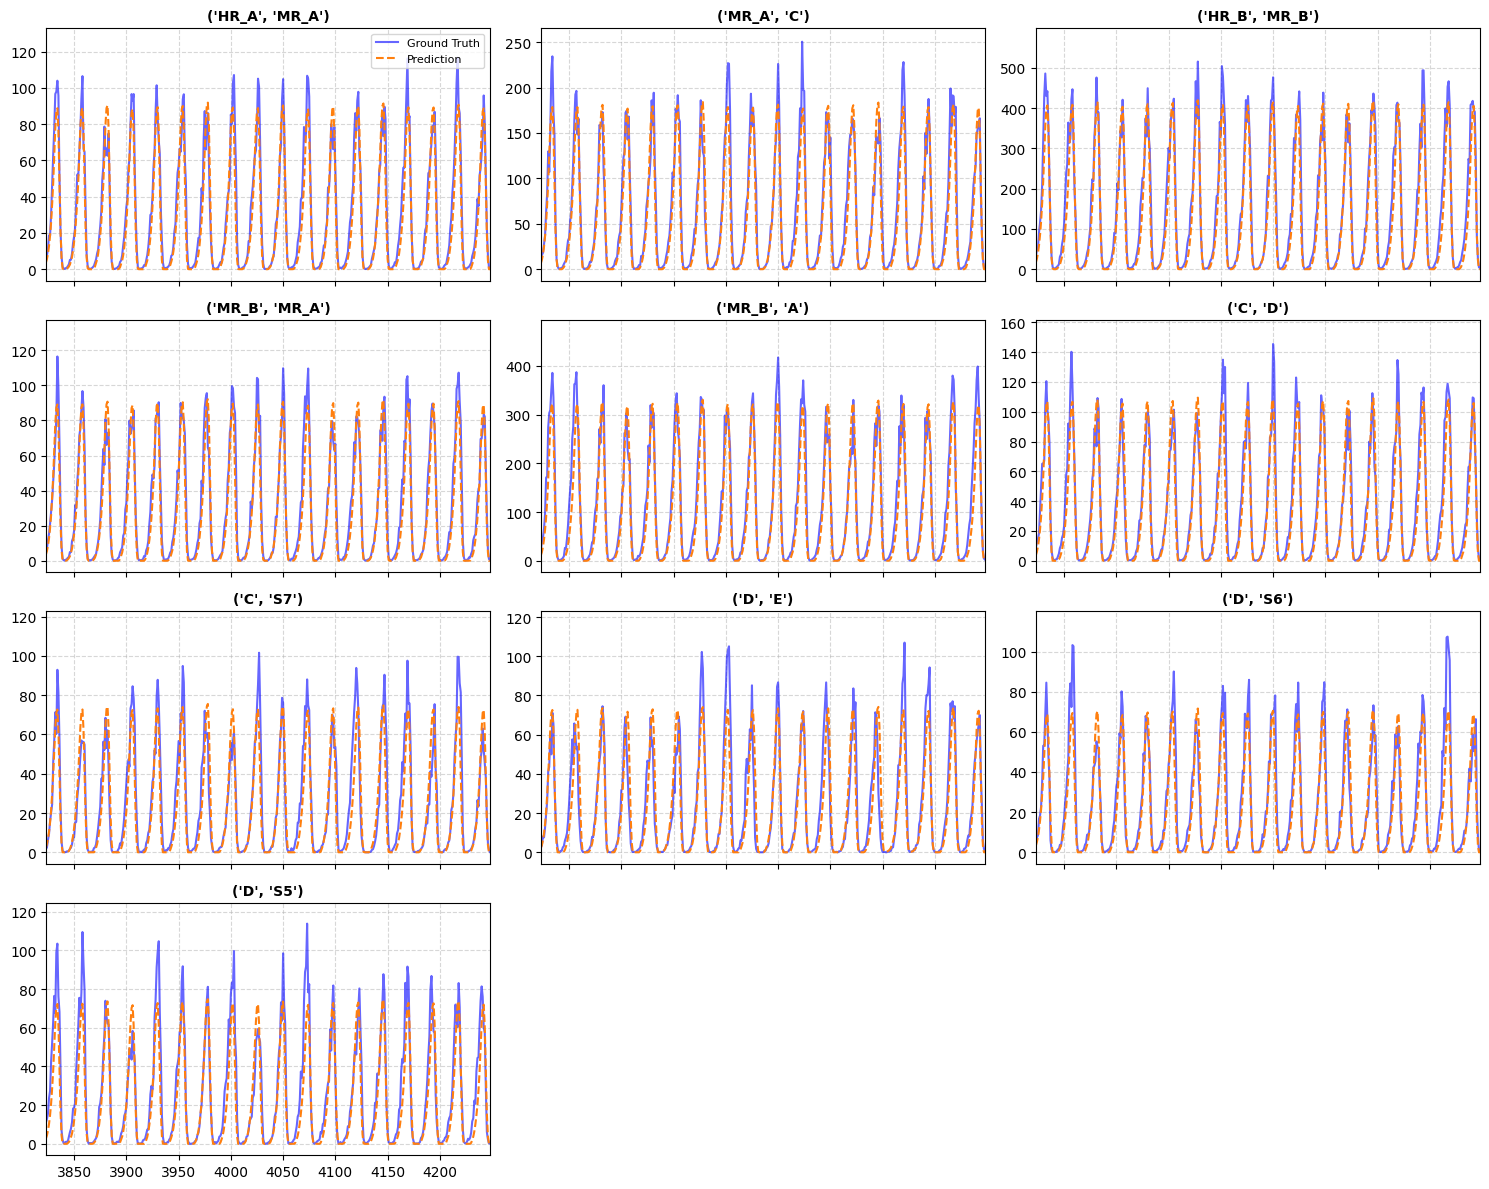

{'loss': 0.10872463969293272,
 'mae': 9.804587364196777,
 'rmse': 16.63937146833762,
 'mape': 6585.713195800781,
 'r2': 0.9202309846878052}

In [113]:

from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import numpy as np
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def plot_all_channels_grid(trues, preds, timestamps=None, channel_names=None, max_channels=12):
    """
    Plots the Ground Truth vs Prediction for multiple channels in a grid.
    
    Args:
        trues: Numpy array of actual traffic [Time_Steps, Num_Nodes].
        preds: Numpy array of predicted traffic [Time_Steps, Num_Nodes].
        timestamps: (Optional) Array of datetime objects for the x-axis.
        channel_names: (Optional) List of names for each node.
        max_channels: The maximum number of channels to plot (to prevent memory crash).
    """
    num_nodes = trues.shape[1]
    
    # Cap the number of channels to plot
    nodes_to_plot = min(num_nodes, max_channels)
    
    # Determine grid size (e.g., 12 plots = 4 rows x 3 columns)
    cols = 3
    rows = math.ceil(nodes_to_plot / cols)
    
    # Create the figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3), sharex=True)
    axes = axes.flatten() # Flatten so we can iterate easily
    
    # Generate X-axis (Use timestamps if provided, otherwise use step index)
    if timestamps is not None:
        x_axis = timestamps
    else:
        x_axis = np.arange(trues.shape[0])

    print(f"Plotting {nodes_to_plot} channels...")

    for i in range(nodes_to_plot):
        ax = axes[i]
        
        # Plot Truth and Prediction
        ax.plot(x_axis, trues[:, i], label='Ground Truth', color='blue', alpha=0.6, linewidth=1.5)
        ax.plot(x_axis, preds[:, i], label='Prediction', color='#ff7f0e', linestyle='--', linewidth=1.5)
        
        # Title and Labels
        ch_name = channel_names[i] if channel_names is not None else f"Channel {i}"
        ax.set_title(ch_name, fontsize=10, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Only show legend on the first plot to save space
        if i == 0:
            ax.legend(loc='upper right', fontsize=8)

    # Format the X-axis for dates if timestamps are provided
    if timestamps is not None:
        for ax in axes:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Hide any unused subplots (if nodes_to_plot is not a multiple of cols)
    for j in range(nodes_to_plot, len(axes)):
        fig.delaxes(axes[j])

    left_bound = x_axis[-1] - (0.1 * (x_axis[-1] - x_axis[0]))
    plt.xlim(left_bound, x_axis[-1])

    plt.tight_layout()
    plt.show()


def calculate_mape(y_true, y_pred):
    """Calculates Mean Absolute Percentage Error, avoiding division by zero."""
    mask = y_true > 1e-5 # Filter out near-zero values to prevent inf
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def validate(model, val_loader, criterion, device, plot=False, channel_names=None, max_channels=12):
    """
    Evaluates the model on the Validation Set.
    Calculates and prints real-unit metrics (MAE, MSE, RMSE, MAPE, R2).
    If plot=True, it will generate a grid chart of predictions vs. ground truth.
    """
    model.eval() # Set model to evaluation mode
    total_val_loss = 0.0
    
    # Lists to store batch results
    all_preds = []
    all_trues = []
    
    with torch.no_grad(): # Disable gradient calculation
        for X, TE, Y in val_loader:
            X = X.to(device)
            TE = TE.to(device)
            Y = Y.to(device)

            X_mask = X.clone()
            #X_mask[:,:,~LEAF_MASK,:] = 0
            
            # Forward pass
            Y_pred = model(X_mask, TE)
            
            # Calculate scaled loss for training monitoring
            loss = criterion(Y_pred, Y)
            total_val_loss += loss.item() * X.size(0)
            
            # Store predictions for METRICS and PLOTTING
            # We take the first prediction step [:, 0, :, 0]
            all_preds.append(Y_pred[:, 0, :, 0].cpu().numpy())
            all_trues.append(Y[:, 0, :, 0].cpu().numpy())
            
    # Calculate average SCALED loss
    avg_val_loss = total_val_loss / len(val_loader.dataset)
    
    # --- 1. PREPARE REAL DATA ---
    # Concatenate all batches chronologically
    final_preds_scaled = np.concatenate(all_preds, axis=0)
    final_trues_scaled = np.concatenate(all_trues, axis=0)
    
    # Denormalize to get real Gbps
    final_preds = (final_preds_scaled * val_loader.dataset.std) + val_loader.dataset.mean
    final_trues = (final_trues_scaled * val_loader.dataset.std) + val_loader.dataset.mean
    
    # Force negative predictions to 0 (physics constraint)
    final_preds = np.maximum(final_preds, 0)

    print(final_trues.shape)

    # --- 2. CALCULATE GLOBAL METRICS (Real Units) ---
    mae = mean_absolute_error(final_trues[:,~LEAF_MASK], final_preds[:,~LEAF_MASK])
    mse = mean_squared_error(final_trues[:,~LEAF_MASK], final_preds[:,~LEAF_MASK])
    rmse = np.sqrt(mse)
    mape = calculate_mape(final_trues[:,~LEAF_MASK], final_preds[:,~LEAF_MASK])
    r2 = r2_score(final_trues[:,~LEAF_MASK], final_preds[:,~LEAF_MASK])

    print("\n" + "="*40)
    print("📈 GLOBAL VALIDATION METRICS (Real Gbps)")
    print("="*40)
    print(f"MAE  (Mean Abs Error):       {mae:.4f} Gbps")
    print(f"RMSE (Root Mean Sq Error):   {rmse:.4f} Gbps")
    print(f"MSE  (Mean Sq Error):        {mse:.4f} Gbps²")
    print(f"MAPE (Mean Abs % Error):     {mape:.2f} %")
    print(f"R²   (Explained Variance):   {r2:.4f}")
    print("="*40)

    # --- 3. CALCULATE PER-CHANNEL MAE ---
    # axis=0 averages over the time dimension, leaving an array of size (Num_Channels)
    per_channel_mae = np.mean(np.abs(final_preds - final_trues), axis=0)
    
    print("\n--- Validation MAE per Channel (Gbps) ---")
    num_nodes = final_preds.shape[1]
    
    # Print the top 10 worst channels (highest error)
    worst_indices = np.argsort(per_channel_mae)[::-1][:10]
    for idx in worst_indices:
        ch_name = channel_names[idx] if channel_names is not None else f"Channel {idx}"
        print(f"{ch_name}: {per_channel_mae[idx]:.4f} Gbps")
    print("...")

    # --- 4. PLOTTING LOGIC ---
    if plot:
        print("\n📊 Generating Validation Plots...")
        plot_all_channels_grid(
            trues=final_trues, 
            preds=final_preds, 
            channel_names=channel_names, 
            max_channels=max_channels
        )
        
    # Return the dictionary of metrics in case you want to log them (e.g., to TensorBoard/WandB)
    metrics = {
        'loss': avg_val_loss,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'r2': r2
    }
    
    return metrics

def validate_gman_reconstruction(model, data_loader, leaf_mask, device, scaler=None):
    """
    model: GMAN model
    data_loader: returns (X, TE, Y)
    leaf_mask: Boolean tensor [Nodes] (True for leaves)
    scaler: Optional dictionary or object with .mean and .std for real-unit MAE
    """
    model.eval()
    
    total_mse = 0
    total_mae = 0
    num_samples = 0
    internal_mask = ~leaf_mask  # The edges we want to reconstruct
    
    with torch.no_grad():
        for X, TE, Y in data_loader:
            X, TE, Y = X.to(device), TE.to(device), Y.to(device)
            
            # 1. MASKING: Hide internal nodes in the input X
            X_masked = X.clone()
            X_masked[:, :, internal_mask, :] = 0.0
            
            # 2. INFERENCE: GMAN predicts Y_hat [Batch, Time_Out, Nodes, 1]
            Y_hat = model(X_masked, TE)
            
            # 3. SELECT INTERNAL EDGES FOR EVALUATION
            # We only evaluate the model's ability to 'fill in' the hidden pipes
            pred_internal = Y_hat[:, :, internal_mask, :]
            true_internal = Y[:, :, internal_mask, :]
            
            # 4. METRICS (Scaled Space)
            mse_batch = torch.mean((pred_internal - true_internal) ** 2)
            
            # Optional: Denormalize for a more meaningful MAE
            if scaler is not None:
                # Assuming simple Z-score: (x * std) + mean
                # You must align scaler indices with internal_mask
                p_real = (pred_internal * scaler.std[internal_mask]) + scaler.mean[internal_mask]
                t_real = (true_internal * scaler.std[internal_mask]) + scaler.mean[internal_mask]
                mae_batch = torch.mean(torch.abs(p_real - t_real))
            else:
                mae_batch = torch.mean(torch.abs(pred_internal - true_internal))
            
            batch_size = X.size(0)
            total_mse += mse_batch.item() * batch_size
            total_mae += mae_batch.item() * batch_size
            num_samples += batch_size

    avg_mse = total_mse / num_samples
    avg_rmse = np.sqrt(avg_mse)
    avg_mae = total_mae / num_samples

    print(f"--- GMAN Internal Reconstruction ---")
    print(f"MSE:  {avg_mse:.6f}")
    print(f"RMSE: {avg_rmse:.6f}")
    print(f"MAE:  {avg_mae:.6f}")
    
    return {"mse": avg_mse, "rmse": avg_rmse, "mae": avg_mae}

VAL_TSS_DS = NetworkTrafficDataset(
    dataframe=DATA_RAW_MODEL, 
    num_his=HIST_STEPS, 
    num_pred=PRED_STEPS, 
    time_slot_hours=FREQ_H,
    mean=TSS_TRAIN_DS.mean,
    std=TSS_TRAIN_DS.std,
    )

VAL_TSS_DL = DataLoader(VAL_TSS_DS, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

config = {
        'num_his': HIST_STEPS,          # History window size
        'num_pred': PRED_STEPS,         # Prediction window size
        'K': K_HEADS,                 # Attention heads
        'd': D_HEAD,                 # Head dimension
        'L': LAYERS_ENC_DEC,                 # Number of blocks
        'bn_decay': 0.1,
        'steps_per_day': STEPS_PER_DAY,
        'batch_size': BATCH_SIZE,
        'epochs': 20,
        'lr': 0.001,
        'num_nodes': NUM_NODES,
        #'spatial_mask': None #ATT_A.to(device),   
    }


MODEL = GMAN(
        NODE_VECTORS,
        config
).to(device)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

validate(MODEL, VAL_TSS_DL, nn.MSELoss(), device, plot=True, channel_names=DATA_RAW_MODEL.columns, max_channels=10)

#validate_gman_reconstruction(MODEL, VAL_TSS_DL, LEAF_MASK, device)  


# PREDICTION

In [114]:
def prediction(model, data:pd.DataFrame, dataset_obj,hist_steps, pred_steps, device='cpu'):

    model.eval()
    model.to(device)
    _dates_pred = pd.date_range(start=data.index[-1] + pd.Timedelta(hours=1), periods=PRED_STEPS, freq='h')
    
    _pred_ds = NetworkTrafficDataset(
                    dataframe=data, 
                    num_his=hist_steps, 
                    num_pred=pred_steps, 
                    time_slot_hours=FREQ_H,
                    mean=dataset_obj.mean,
                    std=dataset_obj.std,
                    is_inference=False
                )

    _pred_dl = DataLoader(_pred_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    with torch.no_grad():
        
        for X, TE,Y in _pred_dl:
            pass

        X = X[-1:].to(device)
        X_masked = X.clone()
        X_masked[:, :, ~LEAF_MASK, :] = 0.0
        TE = TE[-1:].to(device)
        
        _pred = model(X_masked, TE)
    
    _pred = dataset_obj.reverse_transform(_pred)

    _pred_df = pd.DataFrame(_pred[-1].squeeze(-1), index=_dates_pred, columns=data.columns)

    return _pred_df

MODEL = GMAN(
        NODE_VECTORS,
        config
)

print(f"Retrieving model from {SAVE_PATH}")
state_dict = torch.load(SAVE_PATH, map_location=device)
MODEL.load_state_dict(state_dict)

PRED_DATA = DATA_RAW_MODEL.copy()
last_timestamp = PRED_DATA.index[-1]

print(f"the last timestamp is {last_timestamp}")
DAYS_PREDICT = 30

for _ in range(DAYS_PREDICT):

    print(f"Predicting day {_}")
    PRED_DATA = pd.concat([
        PRED_DATA, 
        prediction(MODEL, PRED_DATA, TSS_TRAIN_DS, HIST_STEPS, PRED_STEPS)
        ], axis=0)

PRED_DATA = PRED_DATA[PRED_DATA.index > last_timestamp]


Retrieving model from timeseries_GMAN_model_flow_loss_v4.pth
the last timestamp is 2024-06-28 23:00:00
Predicting day 0
Predicting day 1
Predicting day 2
Predicting day 3
Predicting day 4
Predicting day 5
Predicting day 6
Predicting day 7
Predicting day 8
Predicting day 9
Predicting day 10
Predicting day 11
Predicting day 12
Predicting day 13
Predicting day 14
Predicting day 15
Predicting day 16
Predicting day 17
Predicting day 18
Predicting day 19
Predicting day 20
Predicting day 21
Predicting day 22
Predicting day 23
Predicting day 24
Predicting day 25
Predicting day 26
Predicting day 27
Predicting day 28
Predicting day 29


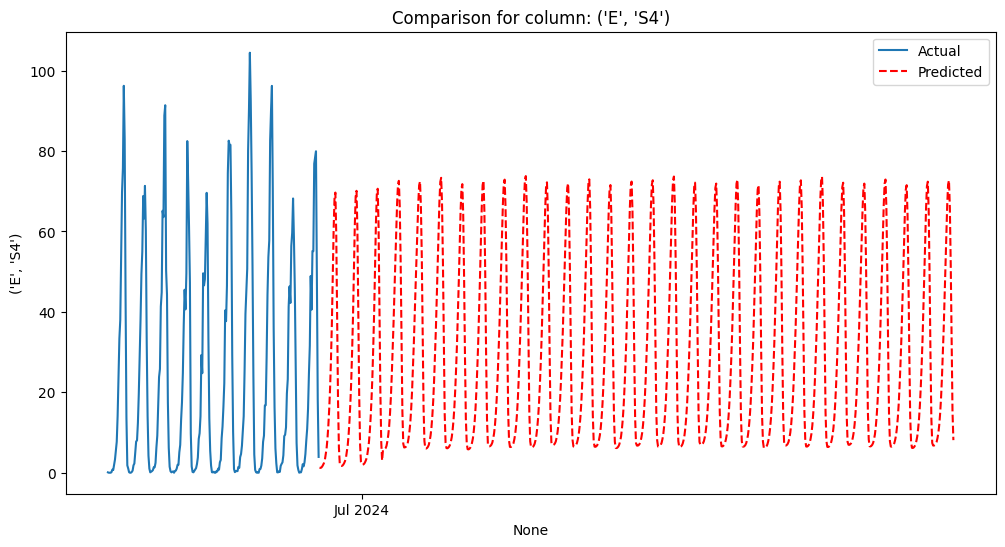

In [115]:
import random
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

column = random.choice(PRED_DATA.columns)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(x=DATA_RAW_MODEL.iloc[-HIST_STEPS*5:][column].index, y=DATA_RAW_MODEL.iloc[-HIST_STEPS*5:][column], label='Actual', ax=ax)
sns.lineplot(x=PRED_DATA.index, y=PRED_DATA[column], label='Predicted', color='red', linestyle='--', ax=ax)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))


plt.title(f"Comparison for column: {column}")
plt.legend()    
plt.show()